In [1]:
import os

# Cell 1: Imports
import numpy as np
import scipy.io
import scipy.signal
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.spatial.distance import cdist
from numpy.lib.stride_tricks import sliding_window_view
from scipy.linalg import eigh,eig
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.cross_decomposition import CCA
from scipy.signal import butter, filtfilt, welch, find_peaks, resample
from sklearn.decomposition import FastICA
from scipy.signal import periodogram
from scipy.signal import medfilt
from scipy.signal import butter, filtfilt
exec(open("Functions.py").read())

In [2]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"


In [44]:
def window_vector_to_signal(v, signal_length, lag, jump, fill_value=0.0):
    """
    Map window-level values to a signal-length vector by placing
    each value at the center of its window.

    Parameters
    ----------
    v : array-like, shape (n_windows,)
        Window-level values.
    signal_length : int
        Length of original ECG signal.
    lag : int
        Length L of each window.
    window_start_indices : array-like, shape (n_windows,)
        Start index t_k of each window.
    fill_value : float, optional
        Value for non-window-center samples (default: 0).

    Returns
    -------
    s : ndarray, shape (signal_length,)
        Signal-level vector with window values at centers.
    """
    window_start_indices = np.arange(0, signal_length - lag, jump)
    s = np.full(signal_length, fill_value, dtype=float)
    half = lag // 2

    for k, val in enumerate(v):
        center = window_start_indices[k] + half
        if 0 <= center < signal_length:
            s[center] = val

    return s


In [52]:
len(np.arange(0, 60000 - 8, 7))

8571

In [47]:
vvv = np.array([1,2,3,7,8,3,4,8,9]*1000)
vvv.shape

(9000,)

In [48]:
window_vector_to_signal(vvv, 59999, lag, jump, fill_value=0.0)

IndexError: index 8571 is out of bounds for axis 0 with size 8571

In [10]:
import numpy as np
from scipy.signal import find_peaks
from sklearn.metrics import auc
import mir_eval
import numpy as np

def collapse_windows_to_centers(binary_vec, mode="center"):
    """
    mode:
      "center"  → midpoint of the window
      "left"    → first index
      "right"   → last index
    """
    binary_vec = np.asarray(binary_vec, dtype=int)
    out = np.zeros_like(binary_vec)

    # find rising and falling edges
    padded = np.pad(binary_vec, (1, 1))
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends   = np.where(diff == -1)[0] - 1

    for s, e in zip(starts, ends):
        if mode == "center":
            idx = (s + e) // 2
        elif mode == "left":
            idx = s
        elif mode == "right":
            idx = e
        else:
            raise ValueError("Unknown mode")

        out[idx] = 1

    return out


def add_tolerance(binary_vec, window):
    """
    window = number of samples to extend on EACH side
    """
    kernel = np.ones(2 * window + 1, dtype=int)
    return (np.convolve(binary_vec, kernel, mode='same') > 0).astype(int)
    
def coverage_PR_AUC(score_signal, gt, fs, thresholds=None, tolerance_window=1, check_sign=True):
    """
    Compute event-level PR-AUC for a continuous score_signal.
    
    Parameters
    ----------
    score_signal : ndarray
        Continuous score vector (mapped to original ECG length).
    gt : list or ndarray
        Ground truth event times in seconds.
    fs : float
        Sampling rate of the score_signal (samples/sec).
    thresholds : array-like, optional
        Thresholds to sweep over. If None, 200 linearly spaced thresholds between min and max.
    tolerance_sec : float
        Temporal tolerance for matching events (seconds).
        
    Returns
    -------
    precision_arr, recall_arr, pr_auc : ndarray, ndarray, float
    """
    #Check sign alignment for eigenvectors scores:
    if check_sign:
        if abs(score_signal.min()) > abs(score_signal.max()):
            score_signal = -score_signal
    

    if thresholds is None:
        # pos_sig = score_signal[score_signal>=0]
        # neg_sig = score_signal[score_signal<=0]
        # l_b = np.min(score_signal)+0.1*np.std(neg_sig)
        # u_b = np.max(score_signal)-0.1*np.std(pos_sig)
        thresholds = np.linspace(np.min(score_signal), np.max(score_signal)-1e-5, 200)
    
    precision_arr = []
    recall_arr = []

    for thr in thresholds:
        # detect peaks above threshold
        est_s = score_signal>thr  # distance=int(0.2*fs) optional refractory period
        
        # compute confusion with gt:
        cm = confusion_matrix(gt, est_s)
        # Unpack the values
        TN, _, _, _ = cm.ravel()

        #compute tolerance-gt and confusion:
        tol_gt = add_tolerance(gt, tolerance_window)
        cm = confusion_matrix(tol_gt, est_s)
        # Unpack the values
        _, FP, _, TP = cm.ravel()

        #compute tolerance-signal and confusion for FN:
        # if gt is suppose to detect the estimation with a window - FP is actually FN of the estimation...
        tol_sig = add_tolerance(est_s, tolerance_window)
        cm = confusion_matrix(tol_sig, gt)
        # Unpack the values
        _, FN, _, _ = cm.ravel()

        #compute precision and recall:
        prec = TP/(TP+FP)
        rec = TP/(TP+FN)
        
        precision_arr.append(prec)
        recall_arr.append(rec)
    
    precision_arr = np.array(precision_arr)
    recall_arr = np.array(recall_arr)
    
    # compute PR-AUC using trapezoidal integration
    # sort by recall ascending for correct integration
    sorted_idx = np.argsort(recall_arr)
    pr_auc = auc(recall_arr[sorted_idx], precision_arr[sorted_idx])
    
    return precision_arr, recall_arr, pr_auc


In [3]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_vec_binary(s, y, return_pr_auc=False):
    """
    Evaluate a continuous vector against a binary ground-truth vector.

    Parameters
    ----------
    s : array-like, shape (n,)
        Continuous scores.
    y : array-like, shape (n,)
        Binary ground-truth labels (0/1).
    return_pr_auc : bool, optional
        If True, also return PR-AUC.

    Returns
    -------
    auc : float
        ROC-AUC score, corrected for ICA sign ambiguity.
    pr_auc : float (optional)
        Precision-Recall AUC (if requested).
    """

    s = np.asarray(s).ravel()
    y = np.asarray(y).ravel()

    # --- ROC-AUC with sign ambiguity ---
    auc_pos = roc_auc_score(y, s)
    auc_neg = roc_auc_score(y, -s)
    auc = max(auc_pos, auc_neg)

    if return_pr_auc:
        pr_pos = average_precision_score(y, s)
        pr_neg = average_precision_score(y, -s)
        pr_auc = max(pr_pos, pr_neg)
        return {"ROC-AUC":auc, "PC-AUC":pr_auc}

    return {"ROC-AUC":auc}


In [4]:
def highpass_filter(sig, fs=1000, cutoff=0.5, order=5):
    b, a = butter(order, cutoff / (0.5 * fs), btype='highpass')
    return filtfilt(b, a, sig)


# def remove_baseline_median(sig, fs=1000, window_ms=500):
#     w = int(fs * window_ms / 1000)
#     baseline = medfilt(sig, kernel_size=w if w % 2 else w+1)
#     return sig - baseline

def remove_baseline_median(sig, window_size=101):
    baseline = medfilt(sig, kernel_size=window_size)
    return sig - baseline
    
def lowpass_filter(sig, fs=1000, cutoff=100, order=5):
    b, a = butter(order, cutoff / (0.5 * fs), btype='lowpass')
    return filtfilt(b, a, sig)


def preprocess_ecg(sig, fs=1000):
    sig = lowpass_filter(sig, fs, cutoff=100)          # step 1: low-pass <100 Hz
    sig = remove_baseline_median(sig, window_size=101) # step 2: remove trend
    sig = (sig - np.mean(sig)) / np.std(sig)           # step 3: normalize
    return sig
    
# def preprocess_ecg(sig, fs=1000):
#     sig = remove_baseline_median(sig, fs)
#     sig = highpass_filter(sig, fs, cutoff=0.5)
#     sig = (sig - np.mean(sig)) / np.std(sig)
#     return sig

def const_lag(sig, lag, jump):
    N = len(sig)
    # Build lagged matrix like MATLAB lagmatrix
    lags = np.column_stack([np.roll(sig, -k) for k in range(lag+1)])
    # Trim the last lag rows that wrapped around
    lags = lags[:N-lag, :]
    # Subsample rows with step = jump
    lags = lags[::jump, :]
    
    return lags

def const_lags(sig, win_size=12, step=6):
    windows = sliding_window_view(sig, win_size)
    return windows[::step]


def map_annotation_to_lagged(annotation, lag=8, step=7):
    """
    annotation : 1D array of 0/1, length T
    lag        : window size
    step       : jump between windows

    returns    : 1D array of length N (number of lagged windows)
    """
    # all overlapping windows
    windows = sliding_window_view(annotation, lag)

    # subsample by step
    windows = windows[::step]

    # OR over each window
    return (windows.max(axis=1)).astype(int)



def ann_to_lag_rows(ann_samples, N, lag, jump):
    """Convert original annotation sample indices to lag-matrix row indices."""
    ann_samples = np.asarray(ann_samples, dtype=int)
    valid = ann_samples < (N - lag)  # last lag samples were dropped
    ann_samples = ann_samples[valid]
    return (ann_samples // jump).astype(int)

def diffusion_map(X, adaptive=5500):
    if adaptive is not None:
        K = Kernel_matrix(X, adaptive)
    else:
        # Pairwise Euclidean distances
        pairwise_dists = squareform(pdist(X, metric='euclidean'))
        # Kernel scale ε = median of distances (common practice)
        epsilon = np.median(pairwise_dists)
        # Construct affinity matrix using squared distance
        K = np.exp(- (pairwise_dists ** 2) / (epsilon ** 2))
    D_inv = np.diag(1.0 / np.sum(K, axis=1))
    P = D_inv @ K
    Q = K @ D_inv
    # eigvals, eigvecs = eig(P)
    # idx = np.argsort(eigvals)[::-1]
    #eigvecs[:, idx], eigvals[idx]
    return P, Q, K

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def dsstft_librosa(signal, fs=1000, n_fft=256, hop_length=128):
    """
    Approximation of deshape STFT using librosa (without Hilbert)
    """
    # 1. STFT
    S = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
    # 2. Magnitude
    S_mag = np.abs(S)
    # 3. Frequency and time vectors
    freqs = np.linspace(0, fs/2, S_mag.shape[0])
    times = np.arange(S_mag.shape[1]) * hop_length / fs
    return freqs, times, S_mag


    
# --- helper: convert detection indices in subsampled-lag rows -> original sample index ---
def subsampled_row_to_orig_sample(det_sub):
    # det_sub: array-like of indices in the subsampled lag matrix (0..n_rows_sub-1)
    return np.asarray(det_sub, dtype=int) * jump


def evaluate_detections(detections_samples, reference_samples, fs=1000, tol_ms=50):
    """
    Evaluate detection timing with tolerance window ±tol_ms.
    Inputs:
      detections_samples : 1D array-like (sample indices) of detected QRS times (sorted or unsorted)
      reference_samples  : 1D array-like (sample indices) of reference QRS times (sorted or unsorted)
      fs                 : sampling frequency in Hz (default 1000)
      tol_ms             : tolerance in milliseconds (default 50 ms)
    Returns:
      dict with TP, FP, FN, precision, recall, f1, mean_abs_error_ms,
           matched_pairs (list of (det_sample, ref_sample))
    """
    det = np.asarray(detections_samples, dtype=int)
    ref = np.asarray(reference_samples, dtype=int)
    if det.size == 0 and ref.size == 0:
        return {'TP':0,'FP':0,'FN':0,'precision':1.0,'recall':1.0,'f1':1.0,'mean_abs_error_ms':0.0,'matched_pairs':[]}
    det.sort()
    ref.sort()
    tol_samples = int(round(tol_ms ))

    i = 0  # index for det
    j = 0  # index for ref
    matched = []
    while i < len(det) and j < len(ref):
        d = det[i]
        r = ref[j]
        diff = d - r
        if abs(diff) <= tol_samples:
            # match them
            matched.append((d, r))
            i += 1
            j += 1
        else:
            # no match: advance the earlier time
            if d < r:
                # detection earlier than reference (and not within tol) -> false positive
                i += 1
            else:
                # reference earlier than detection (not matched) -> missed (false negative)
                j += 1
    
    
    TP = len(matched)
    FP = len(det) - TP
    FN = len(ref) - TP
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    total_samples = max(det.max() if det.size > 0 else 0,
                    ref.max() if ref.size > 0 else 0) + 1  # +1 if indices start at 0
    TN = total_samples - TP - FP - FN
    TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    balanced_accuracy = 0.5 * (recall + TNR)

    if TP > 0:
        abs_errors_ms = [abs(d - r) / fs * 1000.0 for d, r in matched]
        mean_abs_error_ms = float(np.mean(abs_errors_ms))
    else:
        mean_abs_error_ms = float('nan')

    # RR intervals RMSD
    if len(matched) > 1:
        rr_det_ms = np.diff([d for d, r in matched]) / fs * 1000
        rr_ref_ms = np.diff([r for d, r in matched]) / fs * 1000
        rmsd = float(np.sqrt(np.mean((rr_det_ms - rr_ref_ms)**2)))
    else:
        rmsd = float('nan')
        

    return {
        'TP': TP, 'FP': FP, 'FN': FN,
        'precision': precision, 'recall': recall, 'f1': f1,
        'balanced_accuracy': balanced_accuracy,
        'RMSD': rmsd,
        'mean_abs_error_ms': mean_abs_error_ms
        # 'matched_pairs': matched
    }




In [83]:
# ---- CONFIG ----
data_dir = 'set-a-text'   # 🔹 change this to your actual path
record_id = 'a06'                  # choose one record to load
sampling_rate = 1000               # Hz (from PhysioNet description)

# ---- LOAD SIGNAL ----
signal_file = os.path.join(data_dir, f'{record_id}.csv')

# Skip the first 2 header lines
df = pd.read_csv(signal_file, skiprows=2)

# Rename columns for clarity (first is time, next 4 are ECG channels)
df.columns = ['time', 'ECG1', 'ECG2', 'ECG3', 'ECG4']

# Replace missing values (dashes) with NaN and convert to float
df = df.replace('-', np.nan).astype(float)

print("Signal shape:", df.shape)
print(df.head())

# ---- LOAD ANNOTATIONS (fetal QRS times) ----
ann_file = os.path.join(data_dir, f'{record_id}.fqrs.txt')

# Each line = time in milliseconds
with open(ann_file, 'r') as f:
    ann_ms = np.array([float(line.strip()) for line in f if line.strip() != ''])

ann_samples = ann_ms.astype(int)
ann_full = [1 if i in ann_samples else 0 for i in range(df.shape[0])]
ann_samples_lag = np.max(const_lags(ann_full, win_size=8, step=7),axis=1)

print(f"Loaded {len(ann_samples)} annotations")
print("First few annotation times (sec):", ann_samples[:10])




Signal shape: (59999, 5)
    time  ECG1  ECG2  ECG3  ECG4
0  0.001  -9.4  -9.2   4.7  -4.5
1  0.002  -9.8  -9.7   5.2  -6.0
2  0.003 -10.1 -10.1   5.7  -7.3
3  0.004 -10.2 -10.5   6.1  -8.0
4  0.005 -10.2 -10.9   6.5  -7.8
Loaded 160 annotations
First few annotation times (sec): [ 340  710 1107 1508 1925 2312 2704 3107 3520 3914]


In [82]:
sum(np.max(const_lags(ann_full, win_size=8, step=7),axis=1))

162

In [11]:
na_counts = df.isna().sum()
print("Number of NaNs per column:\n", na_counts)
# Get the names of the two columns with the smallest number of NaNs
best_cols = na_counts[1:].nsmallest(2).index.tolist()

print("\nTwo columns with the fewest NaNs:", best_cols)

# Extract them into a new DataFrame if you want
df_best = df[['ECG1','ECG4']].astype(float)

df_preproc = df_best.apply(lambda x: preprocess_ecg(x))
df_best = df_preproc.interpolate(method='linear', axis=0, limit_direction='both')

Number of NaNs per column:
 time    0
ECG1    0
ECG2    0
ECG3    0
ECG4    0
dtype: int64

Two columns with the fewest NaNs: ['ECG1', 'ECG2']


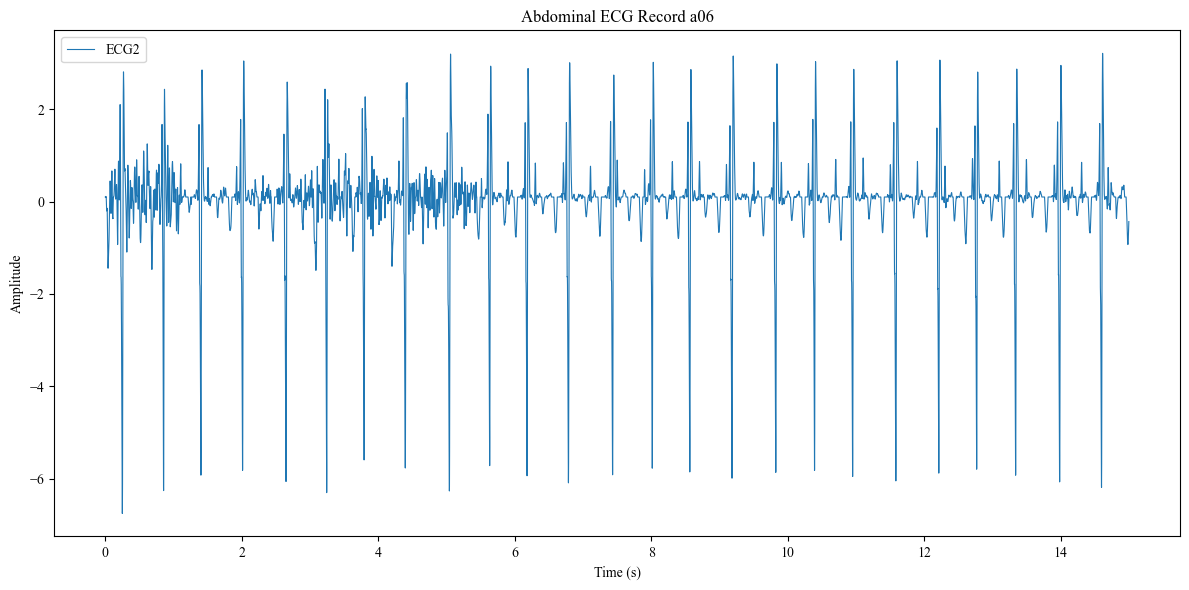

In [12]:
# ---- PLOT ----
plt.figure(figsize=(12, 6))
# plt.plot(df['time'][:15000], df_best_hp['ECG1'][:15000], label='ECG1', lw=0.8)
plt.plot(df['time'][:15000], df_preproc['ECG1'][:15000], label='ECG2', lw=0.8)
# plt.plot(df['time'][:15000], df['ECG1'][:15000], label='ECG2', lw=0.8)

# plt.plot(df['time'][:5000], df_best_detrended['ECG3'][:5000], label='ECG3', lw=0.8)


# # Overlay fetal QRS positions
# plt.scatter(ann_samples, df['ECG1'].iloc[ann_samples], color='red', s=10, label='Fetal QRS')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Abdominal ECG Record {record_id}')
plt.legend()
plt.tight_layout()
plt.show()

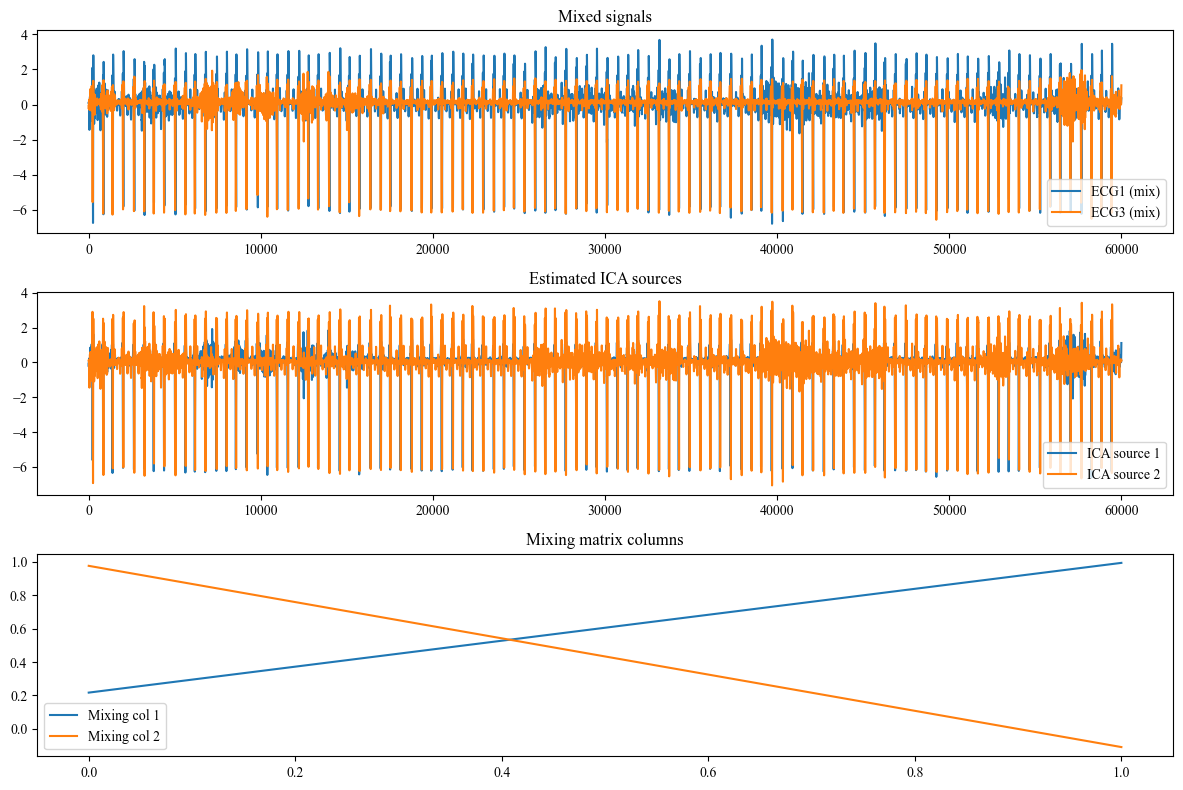

In [13]:
# -------------------------
# 0) prepare mixtures
# -------------------------
# assume sig1, sig2 are numpy arrays length len_sig and fs == 1000
M = df_best   # shape (len_sig, 2)

# 1) standardize channels (zero mean, unit var)
M_std = (M - M.mean(axis=0)) / (M.std(axis=0) + 1e-12)


# 2) run FastICA (2 components)
ica = FastICA(n_components=2, random_state=0, max_iter=5000)
S_est = ica.fit_transform(M_std)   # shape (len_sig, 2)
S_est_norm = normalize(S_est.T).T
A_est = ica.mixing_

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.subplot(3,1,1)
plt.plot(M_std.iloc[:,0], label='ECG1 (mix)')
plt.plot(M_std.iloc[:,1], label='ECG3 (mix)')
plt.legend()
plt.title('Mixed signals')

plt.subplot(3,1,2)
plt.plot(S_est[:,0], label='ICA source 1')
plt.plot(S_est[:,1], label='ICA source 2')
plt.legend()
plt.title('Estimated ICA sources')

plt.subplot(3,1,3)
plt.plot(A_est[:,0], label='Mixing col 1')
plt.plot(A_est[:,1], label='Mixing col 2')
plt.legend()
plt.title('Mixing matrix columns')
plt.tight_layout()
plt.show()



In [14]:

dom = []
for i in range(2):
    f, Pxx = periodogram(S_est[:,i], fs=1000)
    dominant_freq = f[np.argmax(Pxx)]
    dom.append(dominant_freq)
    print(f"Source {i}: dominant frequency = {dominant_freq:.2f} Hz")

Source 0: dominant frequency = 5.02 Hz
Source 1: dominant frequency = 17.53 Hz


NameError: name 'v_ica' is not defined

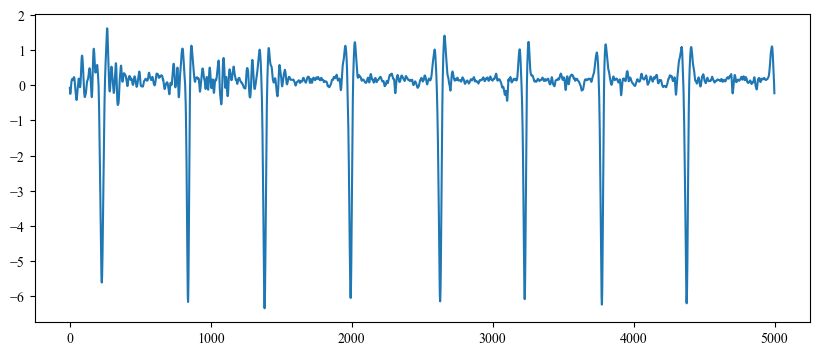

In [15]:
plt.figure(figsize=(10, 4))

# Plot fetal ICA component
plt.plot(S_est[:5000, 0], label='ICA source (candidate fetal)')

# Red dots at detected peaks
plt.scatter(v_ica[v_ica < 5000], S_est[v_ica[v_ica < 5000], 0],
            color='red', s=10, label='Detected (v_ica)')

# Green vertical lines for reference annotations
for a in ann_samples[ann_samples < 5000]:
    plt.axvline(a, color='green', alpha=0.6)

plt.legend()
plt.title('Fetal ICA component vs annotations')
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.show()


In [16]:
v_ica_raw0 = np.abs(S_est[:,0])>np.median(np.abs(S_est[:,0]))+2.5*np.std(np.abs(S_est[:,0]))
v_ica0 = np.where(v_ica_raw0)[0]
v_ica_lag0 = v_ica0/15

v_ica_raw1 = np.abs(S_est[:,1])>np.median(np.abs(S_est[:,1]))+2.5*np.std(np.abs(S_est[:,1]))
v_ica1 = np.where(v_ica_raw1)[0]
v_ica_lag1 = v_ica1/15

In [17]:
len(df_best.iloc[:,0])

59999

In [103]:



lag = 8
jump = 7

siglag1 = const_lags(df_best.iloc[:,0], lag, jump)
siglag2 = const_lags(df_best.iloc[:,1], lag, jump)

ann_samples_lag = ann_to_lag_rows(ann_samples, N=len(df), lag=lag, jump=jump)
gt_lag = [1 if i in ann_samples_lag else 0 for i in range(len(df))]


In [104]:
print(siglag1.shape)

(8571, 8)


IndexError: index 29 is out of bounds for axis 1 with size 8

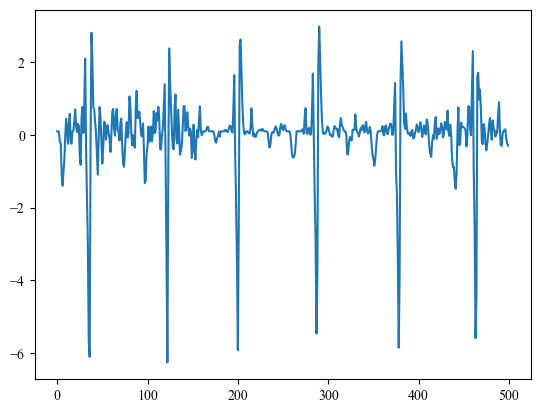

In [105]:
plt.plot(siglag1[:,0][:500])
plt.plot(siglag1[:,29][:500])
# plt.plot(gt_lag[:500])




In [107]:

P1, Q1, K1 = diffusion_map(siglag1,5500)
P2, Q2, K2 = diffusion_map(siglag2,5500)


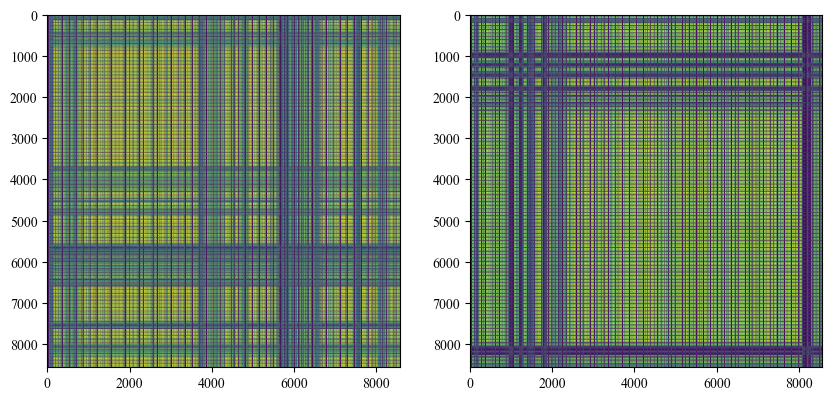

In [108]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(K1)
ax[1].imshow(K2)


In [109]:
# Cell 6: Construct S and A operators and eigenvectors
S = P2 @ Q1 + P1 @ Q2
D = P2 @ Q1 - P1 @ Q2

# Use eigh for symmetric matrices
ES_vals, VS = eig(S)
VS = VS[:, np.argsort(ES_vals)[::-1]]

EA_vals, VA = eig(D)
VA_imag = np.imag(VA[:, np.argsort(np.imag(EA_vals))[::-1]])
VA_real = np.real(VA[:, np.argsort(np.real(EA_vals))[::-1]])


In [358]:
# K1_ = Kernel_matrix(siglag1, 5500)
# K2_ = Kernel_matrix(siglag2, 5500)


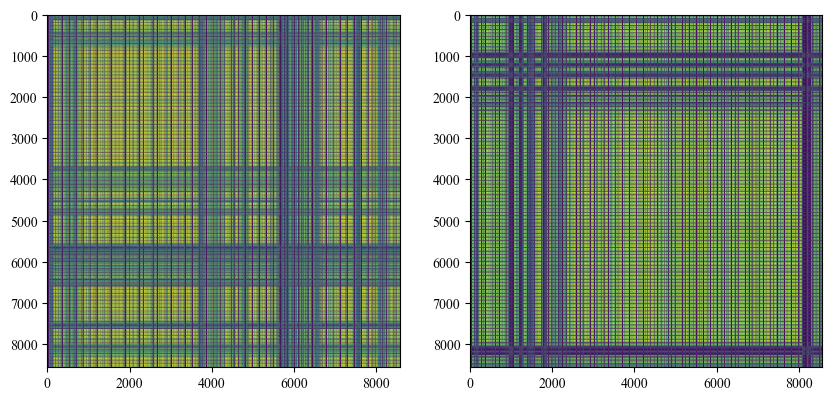

In [359]:
# fig, ax = plt.subplots(1,2,figsize=(10,5))

# ax[0].imshow(K1_)
# ax[1].imshow(K2_)


In [110]:
L1, d1, v1 = LG_sym(K1)
L2, d2, v2 = LG_sym(K2)


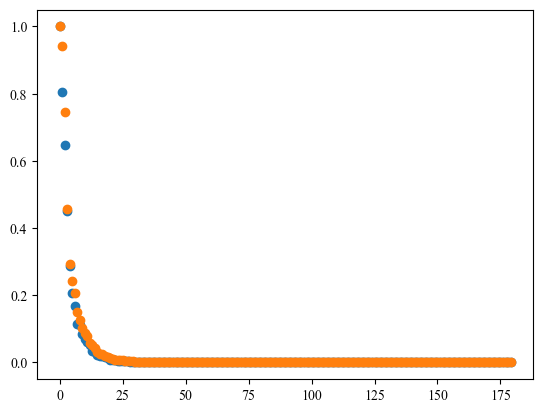

In [111]:
plt.scatter(np.arange(180),d1[:180])
plt.scatter(np.arange(180),d2[:180])


In [112]:
s1, u1 = calc_differential_vec(L2,v1,10)

s2, u2 = calc_differential_vec(L1,v2,10)


In [113]:
#FK transform
  
G1 = np.diag(np.sum(K1, axis=0)) - K1  
G2 = np.diag(np.sum(K2, axis=0)) - K2  

M1 = G1 + 0.0000001 * np.eye(G1.shape[0])
M2 = G2 + 0.0000001 * np.eye(G2.shape[0])

eval_G1, evec_G1 = np.linalg.eigh(M1)
eval_G2, evec_G2 = np.linalg.eigh(M2)

FK1 = np.linalg.inv(M1+M2)@M1
FK2 = np.linalg.inv(M1+M2)@M2

FK_values_1, eig_vec_FK_1 = eig(FK1)
FK_values_2, eig_vec_FK_2 = eig(FK2)

idx_1 = np.argsort(FK_values_1)[::-1]
eig_vec_FK_1 = eig_vec_FK_1[:,idx_1]

idx_2 = np.argsort(FK_values_2)[::-1]
eig_vec_FK_2 = eig_vec_FK_2[:,idx_2]

In [115]:
med_dif = np.median(np.c_[u1[:,:20],u2[:,:20]],axis=1)
med_sh = np.median(np.c_[VA_imag[:,:20],VA_real[:,:20]],axis=1)

v_dif = med_dif>np.median(med_dif)+2.5* np.std(med_dif)
v_sh = med_sh>np.median(med_sh)+2.5* np.std(med_sh)

v_dif_up = subsampled_row_to_orig_sample(np.where(v_dif)[0])
v_sh_up = subsampled_row_to_orig_sample(np.where(v_sh)[0])


In [116]:
res = evaluate_detections(v_dif_up, ann_samples, fs=1000, tol_ms=50)
print(res)

{'TP': 27, 'FP': 133, 'FN': 133, 'precision': 0.16875, 'recall': 0.16875, 'f1': 0.16875, 'balanced_accuracy': 0.5832603316347911, 'RMSD': 35.44551615345184, 'mean_abs_error_ms': 23.814814814814813}


In [117]:
res = evaluate_detections(v_sh_up, ann_samples, fs=1000, tol_ms=50)
print(res)

{'TP': 19, 'FP': 103, 'FN': 141, 'precision': 0.1557377049180328, 'recall': 0.11875, 'f1': 0.1347517730496454, 'balanced_accuracy': 0.5585117605893495, 'RMSD': 29.899832775452108, 'mean_abs_error_ms': 23.63157894736842}


In [118]:
# Example usage:
detect_u1 = np.abs(u1[:, 0]) > np.median(np.abs(u1[:, 0])) + 1 * np.std(np.abs(u1[:, 0]))
detect_u1_up =subsampled_row_to_orig_sample(np.where(detect_u1)[0])

detect_u2 = np.abs(u2[:, 0]) > np.median(np.abs(u2[:, 0])) + 1 * np.std(np.abs(u2[:, 0]))
detect_u2_up = subsampled_row_to_orig_sample(np.where(detect_u2)[0])

detect_sh = np.abs(np.real(VA[:, 1])) >np.median(np.abs(np.real(VA[:, 1]))) + 1 * np.std(np.abs(np.real(VA[:, 1])))
detect_sh_up = subsampled_row_to_orig_sample(np.where(detect_sh)[0])

detect_sh2 = np.abs(np.imag(VA[:, 0])) >np.median(np.abs(np.imag(VA[:, 0]))) + 1 * np.std(np.abs(np.imag(VA[:, 0])))
detect_sh2_up = subsampled_row_to_orig_sample(np.where(detect_sh2)[0])

detect_fkt2 = np.abs(eig_vec_FK_2[:, 1]) > np.median(np.abs(eig_vec_FK_2[:, 0])) +1 * np.std(np.abs(eig_vec_FK_2[:, 0]))
detect_fkt2_up = subsampled_row_to_orig_sample(np.where(detect_u1)[0])

# detections_samples = np.array([1000, 1500, 2000])  # sample indices from your algorithm
# reference_samples  = np.array([995, 1490, 3000])   # from fqrs (converted to samples)
res = evaluate_detections(detect_u1_up, ann_samples, fs=1000, tol_ms=50)
print(res)


{'TP': 72, 'FP': 692, 'FN': 88, 'precision': 0.09424083769633508, 'recall': 0.45, 'f1': 0.15584415584415584, 'balanced_accuracy': 0.7192170446758369, 'RMSD': 46.387073235765605, 'mean_abs_error_ms': 29.77777777777778}


In [119]:
res = evaluate_detections(detect_u2_up, ann_samples, fs=1000, tol_ms=50)
print(res)

{'TP': 131, 'FP': 1227, 'FN': 29, 'precision': 0.09646539027982327, 'recall': 0.81875, 'f1': 0.1725955204216074, 'balanced_accuracy': 0.899098273811518, 'RMSD': 33.631601439488655, 'mean_abs_error_ms': 20.580152671755727}


In [120]:
res = evaluate_detections(detect_sh_up, ann_samples, fs=1000, tol_ms=50)
print(res)

{'TP': 76, 'FP': 1319, 'FN': 84, 'precision': 0.05448028673835126, 'recall': 0.475, 'f1': 0.0977491961414791, 'balanced_accuracy': 0.7264772860222961, 'RMSD': 44.54241424380437, 'mean_abs_error_ms': 26.289473684210527}


In [121]:
res = evaluate_detections(detect_sh2_up, ann_samples, fs=1000, tol_ms=50)
print(res)

{'TP': 44, 'FP': 765, 'FN': 116, 'precision': 0.054388133498145856, 'recall': 0.275, 'f1': 0.09081527347781217, 'balanced_accuracy': 0.6310885616587607, 'RMSD': 45.21550464680358, 'mean_abs_error_ms': 28.727272727272727}


In [5]:

lag = 8
jump = 7

def ecg_check(ids,lag = 8, jump=7, data_dir='set-a-text', tolerances=[50, 100, 150, 200], k=10,K=1500, fs=1000):
    """
    Loop over records, compute multiple detection methods, evaluate, return key metrics.
    """
    results = []

    for record_id in ids:
        # ---- LOAD SIGNAL ----
    
        signal_file = os.path.join(data_dir, f'{record_id}.csv')
        df = pd.read_csv(signal_file, skiprows=2)
        # Replace missing values (dashes) with NaN and convert to float
        df = df.replace('-', np.nan).astype(float)
        df.columns = ['time', 'ECG1', 'ECG2', 'ECG3', 'ECG4']

        # # Pick two best channels (fewest NaNs)
        # na_counts = df.isna().sum()
        # best_cols = na_counts[1:].nsmallest(2).index.tolist()

        df_best = df[['ECG1', 'ECG4']]
        df_best = df_best.apply(lambda x: preprocess_ecg(x))
        # df_best = df_preproc.interpolate(method='linear', axis=0, limit_direction='both')
        
        # ---- LOAD ANNOTATIONS ----
        ann_file = os.path.join(data_dir, f'{record_id}.fqrs.txt')
        with open(ann_file, 'r') as f:
            ann_ms = np.array([float(line.strip()) for line in f if line.strip() != ''])
        ann_samples = ann_ms.astype(int)

        # ---- ICA METHOD ----
        M_std = (df_best - df_best.mean()) / (df_best.std() + 1e-12)
        ica = FastICA(n_components=2, random_state=0, max_iter=5000)
        S_est = ica.fit_transform(M_std)

        # Choose fetal-like ICA component
        dom = []
        for j in range(2):
            f, Pxx = periodogram(S_est[:, j], fs=fs)
            dom.append(f[np.argmax(Pxx)])
        ica_idx = np.argmax(dom)
        ica_idx_non = np.argmin(dom)
        

        v_ica_raw = np.abs(S_est[:, ica_idx]) > np.median(np.abs(S_est[:, ica_idx])) + 2.5 * np.std(np.abs(S_est[:, ica_idx]))
        v_ica_up = np.where(v_ica_raw)[0]

        v_ica_raw2 = np.abs(S_est[:, ica_idx_non]) > np.median(np.abs(S_est[:, ica_idx_non])) + 2.5 * np.std(np.abs(S_est[:, ica_idx_non]))
        v_ica_up2 = np.where(v_ica_raw2)[0]

        # ---- Other detection methods (example placeholders) ----
        
        X1 = df_best.iloc[:,0]
        X2 = df_best.iloc[:,1]
        
        siglag1 = const_lag(X1, lag, jump)
        siglag2 = const_lag(X2, lag, jump)
        
        ann_samples_lag = ann_to_lag_rows(ann_samples, N=len(df), lag=lag, jump=jump)
        gt_lag = [1 if i in ann_samples_lag else 0 for i in range(len(df_best))]

        # ---- Shnitzer et al ---- 
       
        P1, Q1, K1_ = diffusion_map(siglag1)
        P2, Q2, K2_ = diffusion_map(siglag2)
        
        # Cell 6: Construct S and A operators and eigenvectors
        S = P2 @ Q1 + P1 @ Q2
        D = P2 @ Q1 - P1 @ Q2
        
        # Use eigh for symmetric matrices
        ES_vals, VS = eig(S)
        VS = VS[:, np.argsort(ES_vals)[::-1]]
        
        EA_vals, VA = eig(D)
        VA_imag = np.imag(VA[:, np.argsort(np.imag(EA_vals))[::-1]])
        VA_real = np.real(VA[:, np.argsort(np.real(EA_vals))[::-1]])
        
        detect_sh = np.abs(np.real(VA[:, 0])) >np.median(np.abs(np.real(VA[:, 0]))) + 2.5 * np.std(np.abs(np.real(VA[:, 0])))
        detect_sh_up = subsampled_row_to_orig_sample(np.where(detect_sh)[0])
        
        detect_sh2 = np.abs(np.imag(VA[:, 0])) >np.median(np.abs(np.imag(VA[:, 0]))) + 2.5 * np.std(np.abs(np.imag(VA[:, 0])))
        detect_sh2_up = subsampled_row_to_orig_sample(np.where(detect_sh2)[0])

        # med_sh = np.median(np.c_[VA_imag[:,:20],VA_real[:,:20]],axis=1)        
        # v_sh = med_sh>np.median(med_sh)+2* np.std(med_sh)
        # v_sh_up = subsampled_row_to_orig_sample(np.where(v_sh)[0])



        # ---- Differential Method ----
        
        # K1 = Kernel_matrix(siglag1, K)
        # K2 = Kernel_matrix(siglag2, K)

        L1, d1, v1 = LG_sym(K1_)
        L2, d2, v2 = LG_sym(K2_)
    
        s1, u1 = calc_differential_vec(L2,v1,k)
        s2, u2 = calc_differential_vec(L1,v2,k)

        # med_dif = np.median(np.c_[u1[:,:20],u2[:,:20]],axis=1)
        # v_dif = med_dif>np.median(med_dif)+2* np.std(med_dif)

        detect_u1 = np.abs(u1[:, 0]) > np.median(np.abs(u1[:, 0])) + 2.5 * np.std(np.abs(u1[:, 0]))
        detect_u1_up =subsampled_row_to_orig_sample(np.where(detect_u1)[0])
        
        detect_u2 = np.abs(u2[:, 0]) > np.median(np.abs(u2[:, 0])) + 2.5 * np.std(np.abs(u2[:, 0]))
        detect_u2_up =subsampled_row_to_orig_sample(np.where(detect_u2)[0])
       
        # ---- FK transform ---- 
          
        G1 = np.diag(np.sum(K1_, axis=0)) - K1_   
        G2 = np.diag(np.sum(K2_, axis=0)) - K2_   
    
        M1 = G1 + 1e-6 * np.eye(G1.shape[0])
        M2 = G2 + 1e-6 * np.eye(G2.shape[0])
    
        eval_G1, evec_G1 = np.linalg.eigh(M1)
        eval_G2, evec_G2 = np.linalg.eigh(M2)
    
        FK1 = np.linalg.inv(M1+M2)@M1
        FK2 = np.linalg.inv(M1+M2)@M2
    
        FK_values_1, eig_vec_FK_1 = eig(FK1)
        FK_values_2, eig_vec_FK_2 = eig(FK2)
    
        idx_1 = np.argsort(FK_values_1)[::-1]
        eig_vec_FK_1 = eig_vec_FK_1[:,idx_1]
    
        idx_2 = np.argsort(FK_values_2)[::-1]
        eig_vec_FK_2 = eig_vec_FK_2[:,idx_2]

        # med_fkt = np.median(np.c_[eig_vec_FK_1[:,:20],eig_vec_FK_2[:,:20]],axis=1)
        # v_fkt = med_fkt>np.median(med_fkt)+2* np.std(med_fkt)
        # v_fkt_up = subsampled_row_to_orig_sample(np.where(v_fkt)[0])

        detect_fkt1 = np.abs(eig_vec_FK_1[:, 0]) > np.median(np.abs(eig_vec_FK_1[:, 0])) + 2.5 * np.std(np.abs(eig_vec_FK_1[:, 0]))
        detect_fkt1_up =subsampled_row_to_orig_sample(np.where(detect_fkt1)[0])

        detect_fkt2 = np.abs(eig_vec_FK_2[:, 0]) > np.median(np.abs(eig_vec_FK_2[:, 0])) + 2.5 * np.std(np.abs(eig_vec_FK_2[:, 0]))
        detect_fkt2_up =subsampled_row_to_orig_sample(np.where(detect_fkt2)[0])

  
        # Replace these with your computed vectors from your graph/FK/Shnitzer methods
        detect_methods = {
            'ica': v_ica_up,
            'ica sec': v_ica_up2,
            'diff_u1': detect_u1_up,
            'diff_u2': detect_u2_up,
            # 'diff': v_dif_up,
            'sh real': detect_sh_up,
            'sh imag': detect_sh2_up,
            # 'sh': v_sh_up,
            'fkt1': detect_fkt1_up,
            'fkt2': detect_fkt2_up
            # 'fkt': v_fkt_up
        }

        # ---- EVALUATE EACH METHOD ----
        for mname, v_pred in detect_methods.items():
            for tol in tolerances:
                metrics = evaluate_detections(v_pred, ann_samples, fs=fs, tol_ms=tol)
                metrics.update({
                'record': record_id,
                'method': mname,
                'tol': tol
                 })
                # if (tol == 50) and (mname in ['diff', 'sh', 'fkt']):
                #     print(mname)
                #     print(metrics['f1'])
                #     print(metrics['balanced_accuracy'])
                    
                results.append(metrics)
        
        np.save(f"ECG_real_results/{record_id}_metrics.npy", metrics)
        print(record_id)

    return pd.DataFrame(results)


In [6]:

lag = 8
jump = 7

def ecg_save(ids,lag = 8, jump=7, data_dir='set-a-text', tolerances=[50, 100, 150, 200], adaptive=5500, k1=10,k2=15,k3=20,k4=25, fs=1000):
    """
    Loop over records, compute multiple detection methods, and save.
    """

    for record_id in ids:
        # ---- LOAD SIGNAL ----
    
        signal_file = os.path.join(data_dir, f'{record_id}.csv')
        df = pd.read_csv(signal_file, skiprows=2)
        # Replace missing values (dashes) with NaN and convert to float
        df = df.replace('-', np.nan).astype(float)
        df.columns = ['time', 'ECG1', 'ECG2', 'ECG3', 'ECG4']

        df_best = df[['ECG1', 'ECG4']]
        df_best = df_best.apply(lambda x: preprocess_ecg(x))
        # df_best = df_preproc.interpolate(method='linear', axis=0, limit_direction='both')
        
        # ---- LOAD ANNOTATIONS ----
        ann_file = os.path.join(data_dir, f'{record_id}.fqrs.txt')
        with open(ann_file, 'r') as f:
            ann_ms = np.array([float(line.strip()) for line in f if line.strip() != ''])
        ann_samples = ann_ms.astype(int)

        # ---- ICA METHOD ----
        M_std = (df_best - df_best.mean()) / (df_best.std() + 1e-12)
        ica = FastICA(n_components=2, random_state=0, max_iter=5000)
        S_est = ica.fit_transform(M_std)
        
        np.save(f"ECG_real_results/ICA/{record_id}_raw_results.npy", S_est.T)

        # ---- Other detection methods (example placeholders) ----
        
        X1 = df_best.iloc[:,0]
        X2 = df_best.iloc[:,1]
        
        siglag1 = const_lag(X1, lag, jump)
        siglag2 = const_lag(X2, lag, jump)
        
        ann_samples_lag = ann_to_lag_rows(ann_samples, N=len(df), lag=lag, jump=jump)
        gt_lag = [1 if i in ann_samples_lag else 0 for i in range(len(df_best))]

        # ---- Shnitzer et al ---- 
       
        P1, Q1, K1_ = diffusion_map(siglag1, adaptive)
        P2, Q2, K2_ = diffusion_map(siglag2, adaptive)
        
        # Cell 6: Construct S and A operators and eigenvectors
        S = P2 @ Q1 + P1 @ Q2
        D = P2 @ Q1 - P1 @ Q2
        
        # Use eigh for symmetric matrices
        ES_vals, VS = eig(S)
        VS = VS[:, np.argsort(ES_vals)[::-1]]
        
        EA_vals, VA = eig(D)
        VA_imag = np.imag(VA[:, np.argsort(np.imag(EA_vals))[::-1]])
        VA_real = np.real(VA[:, np.argsort(np.real(EA_vals))[::-1]])

        np.save(f"ECG_real_results/Shnitzer/{record_id}_raw_results.npy", np.c_[VA_real[:,:2],VA_imag[:,:2]].T)

        # ---- Differential Method ----
        
        # K1 = Kernel_matrix(siglag1, K)
        # K2 = Kernel_matrix(siglag2, K)
        
        id_results = np.zeros((16,8571))  

        L1, d1, v1 = LG_sym(K1_)
        L2, d2, v2 = LG_sym(K2_)
    
        s1, u11 = calc_differential_vec(L2,v1,k1)
        s2, u12 = calc_differential_vec(L1,v2,k1)

        s1, u21 = calc_differential_vec(L2,v1,k2)
        s2, u22 = calc_differential_vec(L1,v2,k2)

        s1, u31 = calc_differential_vec(L2,v1,k3)
        s2, u32 = calc_differential_vec(L1,v2,k3)

        s1, u41 = calc_differential_vec(L2,v1,k4)
        s2, u42 = calc_differential_vec(L1,v2,k4)
        
        # Save:
        id_results[:2,:] = u11[:,:2].T
        id_results[2:4,:] = u12[:,:2].T
        id_results[4:6,:] = u21[:,:2].T
        id_results[6:8,:] = u22[:,:2].T
        id_results[8:10,:] = u31[:,:2].T
        id_results[10:12,:] = u32[:,:2].T 
        id_results[12:14,:] = u41[:,:2].T
        id_results[14:,:] = u42[:,:2].T 

        np.save(f"ECG_real_results/DiLVE/{record_id}_raw_results.npy", id_results)
    
        # ---- FK transform ---- 
          
        G1 = np.diag(np.sum(K1_, axis=0)) - K1_   
        G2 = np.diag(np.sum(K2_, axis=0)) - K2_   
    
        M1 = G1 + 1e-5 * np.eye(G1.shape[0])
        M2 = G2 + 1e-5 * np.eye(G2.shape[0])
    
        FK1 = np.linalg.inv(M1+M2)@M1
        FK2 = np.linalg.inv(M1+M2)@M2
    
        FK_values_1, eig_vec_FK_1 = eig(FK1)
        FK_values_2, eig_vec_FK_2 = eig(FK2)
    
        idx_1 = np.argsort(FK_values_1)[::-1]
        eig_vec_FK_1 = eig_vec_FK_1[:,idx_1]
    
        idx_2 = np.argsort(FK_values_2)[::-1]
        eig_vec_FK_2 = eig_vec_FK_2[:,idx_2]

        np.save(f"ECG_real_results/FKT/{record_id}_raw_results.npy", np.c_[eig_vec_FK_1[:,:2],eig_vec_FK_2[:,:2]].T)

        print(record_id)



In [217]:

lag = 8
jump = 7

def ecg_save_diff(ids,lag = 8, jump=7, data_dir='set-a-text', adaptive=5500, k1=15,k2=20,k3=25, fs=1000):
    """
    Loop over records, compute multiple detection methods, evaluate, return key metrics.
    """
    results = np.zeros((len(ids),4,8571))
    
    i=0
    for record_id in ids:
        # ---- LOAD SIGNAL ----

        id_results = np.zeros((4,8571))        
    
        signal_file = os.path.join(data_dir, f'{record_id}.csv')
        df = pd.read_csv(signal_file, skiprows=2)
        # Replace missing values (dashes) with NaN and convert to float
        df = df.replace('-', np.nan).astype(float)
        df.columns = ['time', 'ECG1', 'ECG2', 'ECG3', 'ECG4']

        df_best = df[['ECG1', 'ECG4']]
        df_best = df_best.apply(lambda x: preprocess_ecg(x))
        # df_best = df_preproc.interpolate(method='linear', axis=0, limit_direction='both')
        
        # ---- Other detection methods (example placeholders) ----
        
        X1 = df_best.iloc[:,0]
        X2 = df_best.iloc[:,1]
        
        siglag1 = const_lag(X1, lag, jump)
        siglag2 = const_lag(X2, lag, jump)
     
        # ---- Shnitzer et al kernels ---- 
       
        P1, Q1, K1_ = diffusion_map(siglag1, adaptive)
        P2, Q2, K2_ = diffusion_map(siglag2, adaptive)

        # ---- Differential Method ----

        L1, d1, v1 = LG_sym(K1_)
        L2, d2, v2 = LG_sym(K2_)
    
        s1, u11 = calc_differential_vec(L2,v1,k1)
        s2, u12 = calc_differential_vec(L1,v2,k1)

        # s1, u21 = calc_differential_vec(L2,v1,k2)
        # s2, u22 = calc_differential_vec(L1,v2,k2)

        # s1, u31 = calc_differential_vec(L2,v1,k3)
        # s2, u32 = calc_differential_vec(L1,v2,k3)
        # Save:
        id_results[:2,:] = u11[:,:2].T
        id_results[2:4,:] = u12[:,:2].T
        # id_results[4:6,:] = u21[:,:2].T
        # id_results[6:8,:] = u22[:,:2].T
        # id_results[8:10,:] = u31[:,:2].T
        # id_results[10:,:] = u32[:,:2].T 
        results[i,:,:] = id_results

        i += 1
        np.save(f"ECG_real_results/DELVE_5/{record_id}_raw_results.npy", id_results)
        print(record_id)

    return results


In [8]:

lag = 8
jump = 7

def ecg_check_results(ids, SD,  name = "_raw_results",odd_even=0, tolerances=[50, 100, 150, 200], fs=1000):
    """
    Loop over records, compute multiple detection methods, evaluate, return key metrics.
    """
    results = []

    for record_id in ids:
        # ---- LOAD SIGNAL ----
    
        signal_file = os.path.join(data_dir, f'{record_id}.csv')
        df = pd.read_csv(signal_file, skiprows=2)
        # Replace missing values (dashes) with NaN and convert to float
        df = df.replace('-', np.nan).astype(float)
        df.columns = ['time', 'ECG1', 'ECG2', 'ECG3', 'ECG4']

        df_best = df[['ECG1', 'ECG4']]
        df_best = df_best.apply(lambda x: preprocess_ecg(x))
        
        # ---- LOAD ANNOTATIONS ----
        ann_file = os.path.join(data_dir, f'{record_id}.fqrs.txt')
        with open(ann_file, 'r') as f:
            ann_ms = np.array([float(line.strip()) for line in f if line.strip() != ''])
        ann_samples = ann_ms.astype(int)

        # ---- ICA METHOD ----
        M_std = (df_best - df_best.mean()) / (df_best.std() + 1e-12)
        ica = FastICA(n_components=2, random_state=0, max_iter=5000)
        S_est = ica.fit_transform(M_std)

        v_ica_raw = np.abs(S_est[:, 0]) > np.median(np.abs(S_est[:, 0])) + SD * np.std(np.abs(S_est[:, 0]))
        v_ica_up = np.where(v_ica_raw)[0]

        v_ica_raw2 = np.abs(S_est[:, 1]) > np.median(np.abs(S_est[:, 1])) + SD * np.std(np.abs(S_est[:, 1]))
        v_ica_up2 = np.where(v_ica_raw2)[0]

        # ---- Other detection methods (example placeholders) ----
        res_mat = np.load(f"ECG_real_results/{record_id}_{name}.npy")
        res_mat = res_mat[np.arange(odd_even,12,2),:]

        # ---- DiLVE ---- 
        detect_u1 = np.abs(res_mat[0,:]) > np.median(np.abs(res_mat[0,:])) + SD * np.std(np.abs(res_mat[0,:]))
        detect_u1_up =subsampled_row_to_orig_sample(np.where(detect_u1)[0])
        
        detect_u2 = np.abs(res_mat[1,:]) > np.median(np.abs(res_mat[1,:])) + SD * np.std(np.abs(res_mat[1,:]))
        detect_u2_up =subsampled_row_to_orig_sample(np.where(detect_u2)[0])
        
        # ---- Shnitzer ---- 
        detect_sh = np.abs(res_mat[2,:]) >np.median(np.abs(res_mat[2,:])) + SD * np.std(np.abs(res_mat[2,:]))
        detect_sh_up = subsampled_row_to_orig_sample(np.where(detect_sh)[0])
        
        detect_sh2 = np.abs(res_mat[3,:]) >np.median(np.abs(res_mat[3,:])) +SD * np.std(np.abs(res_mat[3,:]))
        detect_sh2_up = subsampled_row_to_orig_sample(np.where(detect_sh2)[0])

        # ---- FK transform ---- 
        detect_fkt1 = np.abs(res_mat[4,:]) >np.median(np.abs(res_mat[4,:])) +SD * np.std(np.abs(res_mat[4,:]))
        detect_fkt1_up =subsampled_row_to_orig_sample(np.where(detect_fkt1)[0])

        detect_fkt2 = np.abs(res_mat[5,:]) >np.median(np.abs(res_mat[5,:])) +SD * np.std(np.abs(res_mat[5,:]))
        detect_fkt2_up =subsampled_row_to_orig_sample(np.where(detect_fkt2)[0])

  
        # Replace these with your computed vectors from your graph/FK/Shnitzer methods
        detect_methods = {
            'ica': v_ica_up,
            'ica sec': v_ica_up2,
            'diff_u1': detect_u1_up,
            'diff_u2': detect_u2_up,
            # 'diff': v_dif_up,
            'sh real': detect_sh_up,
            'sh imag': detect_sh2_up,
            # 'sh': v_sh_up,
            'fkt1': detect_fkt1_up,
            'fkt2': detect_fkt2_up
            # 'fkt': v_fkt_up
        }

        # ---- EVALUATE EACH METHOD ----
        for mname, v_pred in detect_methods.items():
            for tol in tolerances:
                metrics = evaluate_detections(v_pred, ann_samples, fs=fs, tol_ms=tol)
                metrics.update({
                'record': record_id,
                'method': mname,
                'tol': tol
                 })

                results.append(metrics)
        
        # np.save(f"ECG_real_results/{record_id}_metrics.npy", metrics)
        print(record_id)

    return pd.DataFrame(results)


In [13]:
# List all CSV files in the folder
data_dir = 'set-a-text' 
all_files = os.listdir(data_dir)
csv_files = [f for f in all_files if f.endswith('.csv')]

# Extract record IDs (filename without extension)
record_idxs = [os.path.splitext(f)[0] for f in csv_files]

# Record IDs to remove
bad_ids = {'33', '38', '47', '52', '54', '71', '74'}

# Keep only the records not in bad_ids
record_idxs = [r for r in record_idxs if r[1:] not in bad_ids]

print(record_idxs)
print(len(record_idxs))

['a12', 'a06', 'a07', 'a13', 'a39', 'a05', 'a11', 'a10', 'a04', 'a14', 'a28', 'a29', 'a15', 'a01', 'a17', 'a03', 'a02', 'a16', 'a59', 'a65', 'a64', 'a70', 'a58', 'a66', 'a72', 'a73', 'a67', 'a63', 'a62', 'a60', 'a48', 'a49', 'a61', 'a75', 'a50', 'a44', 'a45', 'a51', 'a53', 'a46', 'a42', 'a56', 'a57', 'a43', 'a55', 'a41', 'a69', 'a68', 'a40', 'a27', 'a26', 'a32', 'a18', 'a24', 'a30', 'a31', 'a25', 'a19', 'a21', 'a35', 'a09', 'a08', 'a34', 'a20', 'a36', 'a22', 'a23', 'a37']
68


In [6]:
# ---- Find which records do NOT appear in ECG_real_results ----
results_dir = "ECG_real_results/DELVE_5"
results_files = os.listdir(results_dir)

# Extract IDs (remove extension)
results_ids = {f.split("_")[0] for f in results_files}

# Compute missing IDs
missing_records = [r for r in record_idxs if r not in results_ids]

print("Missing records:", missing_records)
print("Count:", len(missing_records))

Missing records: ['a72', 'a73', 'a67', 'a63', 'a62', 'a60', 'a48', 'a49', 'a61', 'a75', 'a50', 'a44', 'a45', 'a51', 'a53', 'a46', 'a42', 'a56', 'a57', 'a43', 'a55', 'a41', 'a69', 'a68', 'a40', 'a27', 'a26', 'a32', 'a18', 'a24', 'a30', 'a31', 'a25', 'a19', 'a21', 'a35', 'a09', 'a08', 'a34', 'a20', 'a36', 'a22', 'a23', 'a37']
Count: 44


In [ ]:
ecg_save_diff(missing_records,lag = 8, jump=7, data_dir='set-a-text', adaptive=5500, k1=5, fs=1000)

In [11]:
ecg_save(missing_records,lag = 8, jump=7, data_dir='set-a-text', tolerances=[50, 100, 150, 200], adaptive=5500, k1=10,k2=15,k3=20,k4=25, fs=1000)


a12
a06
a07
a13
a39
a05
a11
a10
a04
a14
a28
a29
a15
a01
a17
a03
a02
a16
a59
a65
a64
a70
a58
a66
a72
a73
a67
a63
a62
a60
a48
a49
a61
a75
a50
a44
a45
a51
a53
a46
a42
a56
a57
a43
a55
a41
a69
a68
a40
a27
a26
a32
a18
a24
a30
a31
a25
a19
a21
a35
a09
a08
a34
a20
a36
a22
a23
a37


In [49]:
def detect_vector(u, SD, subsampled_row_to_orig_sample):
    thresh = np.median(np.abs(u)) + SD * np.std(np.abs(u))
    detect = np.abs(u) > thresh
    return subsampled_row_to_orig_sample(np.where(detect)[0])

In [195]:
METHODS = {
    "Shnitzer": {
        "folder": "Shnitzer",
        "n_vecs": 4,
        "labels": ["r1", "i1"], # ["r1", "r2", "i1", "i2"],
    },
    "FKT": {
        "folder": "FKT",
        "n_vecs": 4,
        "labels": ["A1", "B1"], #["A1", "A2", "B1", "B2"],
    },
    "DELVE": {
        "folder": "DELVE",
        "n_vecs": 16,
        "labels": [
            # "k10_A1", "k10_A2", "k10_B1", "k10_B2",
            "k15_A1", "k15_B1", #"k15_A1",  "k15_A2",  "k15_B1",  "k15_B2",
            # "k20_A1",  "k20_A2",  "k20_B1",  "k20_B2",
            # "k25_A1",  "k25_A2",  "k25_B1",  "k25_B2",
        ],
    },
    "ICA": {
        "folder": "ICA",
        "n_vecs": 2,
        "labels": ["a", "b"],
    },
}


In [52]:
from pathlib import Path
import numpy as np

SD=2.5
tolerances=[10, 50, 75, 100, 150]
fs =1000
results = []
jump=7

for record_id in record_idxs:
    ann_file = os.path.join(data_dir, f'{record_id}.fqrs.txt')
    
    # Each line = time in milliseconds
    with open(ann_file, 'r') as f:
        ann_ms = np.array([float(line.strip()) for line in f if line.strip() != ''])
    
    ann_samples = ann_ms.astype(int)
    ann_full = [1 if i in ann_samples else 0 for i in range(df.shape[0])]
    ann_samples_lag = map_annotation_to_lagged(ann_full, lag=8, step=7)


    for mname, spec in METHODS.items():

        path = Path(f"ECG_real_results/{spec['folder']}/{record_id}_raw_results.npy")
        if not path.exists():
            continue

        res_mat = np.load(path)

        # Optional odd/even selection (your existing logic)
        # res_mat = res_mat[np.arange(odd_even, res_mat.shape[0], 2), :]

        assert res_mat.shape[0] == spec["n_vecs"], \
            f"{mname} {record_id}: expected {spec['n_vecs']} rows, got {res_mat.shape[0]}"

        detect_methods = {}

        for i, label in enumerate(spec["labels"]):
            v_up = detect_vector(
                res_mat[i, :],
                SD,
                subsampled_row_to_orig_sample
            )
            detect_methods[f"{mname}_{label}"] = v_up

        # ---- EVALUATION (unchanged) ----
        for method_label, v_pred in detect_methods.items():
            for tol in tolerances:
                metrics = evaluate_detections(
                    v_pred,
                    ann_samples,
                    fs=fs,
                    tol_ms=tol
                )
                metrics.update({
                    "record": record_id,
                    "method": method_label,
                    "tol": tol
                })
                results.append(metrics)


In [62]:
import pandas as pd

results_new = []

for record_id in record_idxs:
    ann_file = os.path.join(data_dir, f'{record_id}.fqrs.txt')

    with open(ann_file, 'r') as f:
        ann_ms = np.array([float(line.strip()) for line in f if line.strip() != ''])

    ann_samples = ann_ms.astype(int)
    ann_full = np.isin(np.arange(59999), ann_samples).astype(int)

    ann_samples_lag = const_lag(ann_full, lag, jump)
    f_true_lag = np.max(ann_samples_lag, axis=1)

    f_true_lag_single = collapse_windows_to_centers(f_true_lag, mode="center")
    f_true_single     = collapse_windows_to_centers(ann_full, mode="center")

    for mname, spec in METHODS.items():

        path = Path(f"ECG_real_results/{spec['folder']}/{record_id}_raw_results.npy")
        if not path.exists():
            continue

        res_mat = np.load(path)

        assert res_mat.shape[0] == spec["n_vecs"], \
            f"{mname} {record_id}: expected {spec['n_vecs']} rows, got {res_mat.shape[0]}"

        for i, label in enumerate(spec["labels"]):

            method_label = f"{mname}_{label}"

            # choose GT + window logic
            if mname == "ICA":
                v_pred = res_mat[i, :]
                # tol_window = w * 7 + 1
                # gt_use = f_true_single
            else:
                v_pred = window_vector_to_signal(res_mat[i, :], 59999, lag, jump, fill_value=0.0)
                # tol_window = w 
                # gt_use = f_true_lag_single

            _, _, pr_auc = coverage_PR_AUC(
                score_signal=v_pred,
                gt=f_true_single,
                fs=1,
                thresholds=None,
                tolerance_window=w,
            )

            # ---- STORE RESULT ----
            results_new.append({
                "record": record_id,
                "method": mname,
                "vector": label,
                "method_vector": method_label,
                "tolerance_window": tol_window,
                "pr_auc": pr_auc,
            })


In [115]:
14*7

98

In [196]:
import pandas as pd
from pathlib import Path
import os
import numpy as np

# Example tolerance windows (in samples)
tolerance_windows = [0,25, 50, 100, 150,200]  # change as needed

results_new = []

for record_id in record_idxs:
    ann_file = os.path.join(data_dir, f'{record_id}.fqrs.txt')

    with open(ann_file, 'r') as f:
        ann_ms = np.array([float(line.strip()) for line in f if line.strip() != ''])

    ann_samples = ann_ms.astype(int)
    ann_full = np.isin(np.arange(59999), ann_samples).astype(int)

    ann_samples_lag = const_lag(ann_full, lag, jump)
    f_true_lag = np.max(ann_samples_lag, axis=1)

    f_true_lag_single = collapse_windows_to_centers(f_true_lag, mode="center")
    f_true_single     = collapse_windows_to_centers(ann_full, mode="center")

    for mname, spec in METHODS.items():

        path = Path(f"ECG_real_results/{spec['folder']}/{record_id}_raw_results.npy")
        if not path.exists():
            continue

        res_mat = np.load(path)

        assert res_mat.shape[0] == spec["n_vecs"], \
            f"{mname} {record_id}: expected {spec['n_vecs']} rows, got {res_mat.shape[0]}"

        for i, label in enumerate(spec["labels"]):

            method_label = f"{mname}_{label}"
            # v_pred = res_mat[i, :]

            # Loop over different tolerance windows
            for w in tolerance_windows:

                # choose GT + window logic
                if mname == "ICA":
                    v_pred = res_mat[i, :]
                    # tol_window = w * 7 + 1
                    # gt_use = f_true_single
                else:
                    v_pred = window_vector_to_signal(np.real(res_mat[i, :]), 59999, lag, jump, fill_value=0.0)
                    # tol_window = w 
                    # gt_use = f_true_lag_single

                _, _, pr_auc = coverage_PR_AUC(
                    score_signal=v_pred,
                    gt=f_true_single,
                    fs=1,
                    thresholds=None,
                    tolerance_window=w,
                )

                # ---- STORE RESULT ----
                results_new.append({
                    "record": record_id,
                    "method": mname,
                    "vector": label,
                    "method_vector": method_label,
                    "tolerance_window": w,
                    "pr_auc": pr_auc,
                })

# Convert to DataFrame for analysis
df_results = pd.DataFrame(results_new)
print(df_results.head())


  record    method vector method_vector  tolerance_window    pr_auc
0    a12  Shnitzer     r1   Shnitzer_r1                 0  0.009239
1    a12  Shnitzer     r1   Shnitzer_r1                25  0.310900
2    a12  Shnitzer     r1   Shnitzer_r1                50  0.370985
3    a12  Shnitzer     r1   Shnitzer_r1               100  0.550580
4    a12  Shnitzer     r1   Shnitzer_r1               150  0.695880


In [197]:
df_group = (
    df_results
    .groupby(["method", "method_vector", "tolerance_window"], as_index=False)
    .agg(pr_auc_mean=("pr_auc", "mean"),
         pr_auc_std=("pr_auc", "std"))
)

df_group["rank"] = (
    df_group
    .groupby("tolerance_window")["pr_auc_mean"]
    .rank(method="dense", ascending=False)
)

In [198]:
df_group

,method,method_vector,tolerance_window,pr_auc_mean,pr_auc_std,rank
0,DELVE,DELVE_k15_A1,0,0.005416,0.006407,4.0
1,DELVE,DELVE_k15_A1,25,0.277729,0.257014,2.0
2,DELVE,DELVE_k15_A1,50,0.375632,0.223235,2.0
3,DELVE,DELVE_k15_A1,100,0.562624,0.159911,2.0
4,DELVE,DELVE_k15_A1,150,0.760358,0.103793,2.0
5,DELVE,DELVE_k15_A1,200,0.938342,0.052502,1.0
6,DELVE,DELVE_k15_B1,0,0.003485,0.003107,8.0
7,DELVE,DELVE_k15_B1,25,0.219305,0.118881,5.0
8,DELVE,DELVE_k15_B1,50,0.350062,0.129762,3.0
9,DELVE,DELVE_k15_B1,100,0.546465,0.097341,3.0


In [199]:
def lighten_color(color, amount=0.5):
    """
    amount=0 -> original color
    amount=1 -> white
    """
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

COLOR_FAMILIES = {
    "DELVE": "tab:blue",
    "Shnitzer": "tab:red",
    "FKT": "tab:green",
    "ICA": "tab:purple",
}

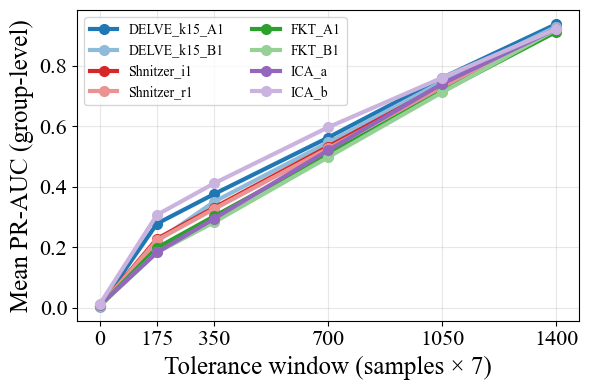

In [200]:
import matplotlib.colors as mcolors

plt.figure(figsize=(6, 4))

for family, base_color in COLOR_FAMILIES.items():

    sub_family = df_group[df_group["method"].str.startswith(family)]
    if sub_family.empty:
        continue

    methods = sub_family["method_vector"].unique()
    shades = np.linspace(0.0, 0.5, len(methods))

    for mv, shade in zip(methods, shades):

        sub = sub_family[sub_family["method_vector"] == mv]
        color = lighten_color(base_color, shade)

        plt.plot(
            sub["tolerance_window"] * 7,
            sub["pr_auc_mean"],
            marker="o",
            linewidth=3.0,
            markersize=7,
            color=color,
            label=mv
        )

# ---- ticks ----
tol_vals = np.sort(df_group["tolerance_window"].unique())
plt.xticks(tol_vals * 7, tol_vals * 7)

plt.tick_params(axis='both', labelsize=16)

plt.xlabel("Tolerance window (samples × 7)", fontsize=18)
plt.ylabel("Mean PR-AUC (group-level)", fontsize=18)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()



In [241]:
VECTOR_RENAME = {
    # DELVE
    "DELVE_k15_A1": "DELVE (A)",
    "DELVE_k15_B1": "DELVE (B)",

    # Shnitzer
    "Shnitzer_r1": "Shnitzer + (real)",
    "Shnitzer_i1": "Shnitzer + (imag)",

    # FKT
    "FKT_A1": "FKT (A)",
    "FKT_B1": "FKT (B)",

    # ICA
    "ICA_a": "ICA (1)",
    "ICA_b": "ICA (2)",
}

FAMILY_ORDER = ["DELVE", "Shnitzer", "FKT", "ICA"]

df_results["method_vector_pretty"] = (
    df_results["method_vector"].map(VECTOR_RENAME)
)

hue_order = []

for fam in FAMILY_ORDER:
    sub = df_results[df_results["method"] == fam]
    # keep the internal order stable
    mvs = sub["method_vector_pretty"].unique()
    hue_order.extend(mvs)

palette_mv = {}

for family, base_color in COLOR_FAMILIES.items():
    sub = df_results[df_results["method"] == family]
    method_vectors = sub["method_vector_pretty"].unique()

    shades = np.linspace(0.0, 0.5, len(method_vectors))

    for mv, shade in zip(method_vectors, shades):
        palette_mv[mv] = lighten_color(base_color, shade)


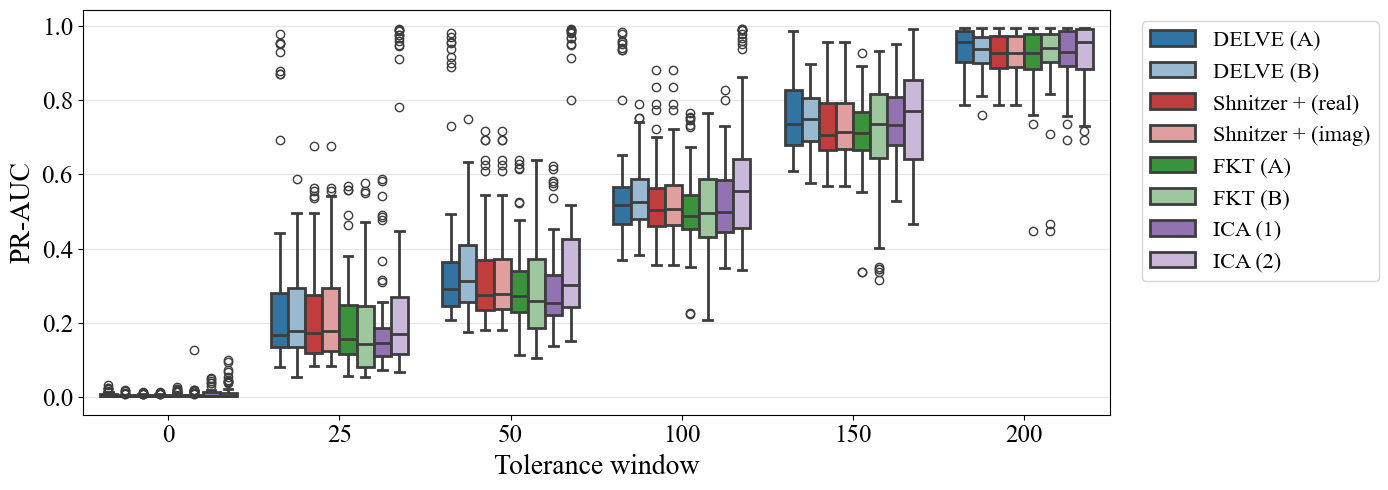

In [242]:
tol_order = sorted(df_results["tolerance_window"].unique())

plt.figure(figsize=(14, 5))

sns.boxplot(
    data=df_results,
    x="tolerance_window",
    y="pr_auc",
    order=tol_order,
    hue="method_vector_pretty",
    hue_order=hue_order,
    palette=palette_mv,
    linewidth=2,
    dodge=True
)

plt.ylabel("PR-AUC", fontsize=20)
plt.xlabel("Tolerance window", fontsize=20)

# plt.title("Group-level PR-AUC across tolerance windows", fontsize=16)

plt.xticks(
    range(len(tol_order)),
    [t  for t in tol_order],
    fontsize=18
)

plt.yticks(fontsize=18)
plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="",
    fontsize=16,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("PR-AUC_real.pdf")
plt.show()


In [229]:
VECTOR_RENAME = {
    # DELVE
    "DELVE_k15_A1": "DELVE (A)",
    "DELVE_k15_B1": "DELVE (B)",

    # Shnitzer
    "Shnitzer_r1": "Shnitzer (real)",
    "Shnitzer_i1": "Shnitzer (imag)",

    # FKT
    "FKT_A1": "FKT (A)",
    "FKT_B1": "FKT (B)",

    # ICA
    "ICA_a": "ICA (1)",
    "ICA_b": "ICA (2)",
}

tols_of_interest = [50, 100]

df_sub = df_results[
    df_results["tolerance_window"].isin(tols_of_interest)
].copy()

summary_table = (
    df_sub
    .groupby(["tolerance_window", "method", "method_vector"])
    .agg(
        Mean=("pr_auc", "mean"),
        Median=("pr_auc", "median"),
        Q25=("pr_auc", lambda x: x.quantile(0.25)),
        Q75=("pr_auc", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

summary_table["IQR"] = summary_table["Q75"] - summary_table["Q25"]


summary_table["method"] = pd.Categorical(
    summary_table["method"],
    categories=FAMILY_ORDER,
    ordered=True
)

summary_table = summary_table.sort_values(
    ["tolerance_window", "method"]
)


summary_table["method_vector"] = (
    summary_table["method_vector"]
    .map(VECTOR_RENAME)
)

summary_table_rounded = summary_table.copy()

for col in ["Mean", "Median", "Q25", "Q75", "IQR"]:
    summary_table_rounded[col] = summary_table_rounded[col].round(3)

summary_table_rounded


,tolerance_window,method,method_vector,Mean,Median,Q25,Q75,IQR
0,50,DELVE,DELVE (A),0.376,0.291,0.246,0.365,0.119
1,50,DELVE,DELVE (B),0.350,0.314,0.256,0.409,0.153
6,50,Shnitzer,Shnitzer (imag),0.331,0.278,0.236,0.373,0.137
7,50,Shnitzer,Shnitzer (real),0.326,0.275,0.234,0.369,0.135
2,50,FKT,FKT (A),0.302,0.272,0.229,0.338,0.109
3,50,FKT,FKT (B),0.283,0.259,0.186,0.371,0.185
4,50,ICA,ICA (1),0.294,0.253,0.221,0.329,0.108
5,50,ICA,ICA (2),0.411,0.301,0.241,0.426,0.185
8,100,DELVE,DELVE (A),0.563,0.517,0.466,0.566,0.100
9,100,DELVE,DELVE (B),0.546,0.526,0.481,0.588,0.108


In [231]:
summary_table_rounded.to_latex(
    "real_ECG_pr_auc.tex",
    float_format="%.3f"
)


In [190]:
rank_within_method = (
    df_results
    .groupby(["method", "vector"])["pr_auc"]
    .mean()
    .reset_index()
    .sort_values(["method", "pr_auc"], ascending=[True, False])
)

print(rank_within_method)


      method  vector    pr_auc
0      DELVE  k15_A1  0.314557
1      DELVE  k15_A2  0.300004
2      DELVE  k15_B1  0.276666
3      DELVE  k15_B2  0.273072
7        FKT      B2  0.287752
6        FKT      B1  0.277451
4        FKT      A1  0.271463
5        FKT      A2  0.262012
9        ICA       b  0.339910
8        ICA       a  0.274385
11  Shnitzer      i2  0.298669
13  Shnitzer      r2  0.289137
12  Shnitzer      r1  0.285530
10  Shnitzer      i1  0.268157


In [180]:
stats = (
    df_results
    .groupby("method_vector")["pr_auc"]
    .agg(["mean", "std"])
    .reset_index()
)

stats["score"] = stats["mean"] - stats["std"]
stats = stats.sort_values("score", ascending=False)

print(stats)


   method_vector      mean       std     score
1   DELVE_k25_A2  0.300004  0.243571  0.056433
10   Shnitzer_i1  0.268157  0.214803  0.053354
11   Shnitzer_i2  0.298669  0.245634  0.053035
13   Shnitzer_r2  0.289137  0.239106  0.050031
12   Shnitzer_r1  0.285530  0.236687  0.048843
3   DELVE_k25_B2  0.273072  0.225771  0.047301
4         FKT_A1  0.271463  0.225895  0.045568
8          ICA_a  0.274385  0.229048  0.045337
2   DELVE_k25_B1  0.276666  0.233480  0.043186
6         FKT_B1  0.277451  0.241742  0.035709
0   DELVE_k25_A1  0.314557  0.280673  0.033885
5         FKT_A2  0.262012  0.232133  0.029878
7         FKT_B2  0.287752  0.257949  0.029802
9          ICA_b  0.339910  0.310359  0.029550


In [111]:
df_results_filtered = df_results[
    (~df_results["method_vector"].str.startswith("DELVE")) |  # keep Shnitzer/FKt
    # (df_results["method_vector"].str.contains("_k20_"))  # only DiLVE k=25
].copy()

df_results_filtered

,record,method,vector,method_vector,tolerance_window,pr_auc
0,a12,Shnitzer,r1,Shnitzer_r1,50,0.370985
1,a12,Shnitzer,r2,Shnitzer_r2,50,0.370985
2,a12,Shnitzer,i1,Shnitzer_i1,50,0.230485
3,a12,Shnitzer,i2,Shnitzer_i2,50,0.824829
4,a12,FKt,A1,FKt_A1,50,0.198396
...,...,...,...,...,...,...
1749,a37,FKt,B2,FKt_B2,50,0.545117
1758,a37,DELVE,k20_A1,DELVE_k20_A1,50,0.386434
1760,a37,DELVE,k20_B1,DELVE_k20_B1,50,0.226915
1766,a37,ICA,a,ICA_a,50,0.380648


<Figure size 600x400 with 0 Axes>

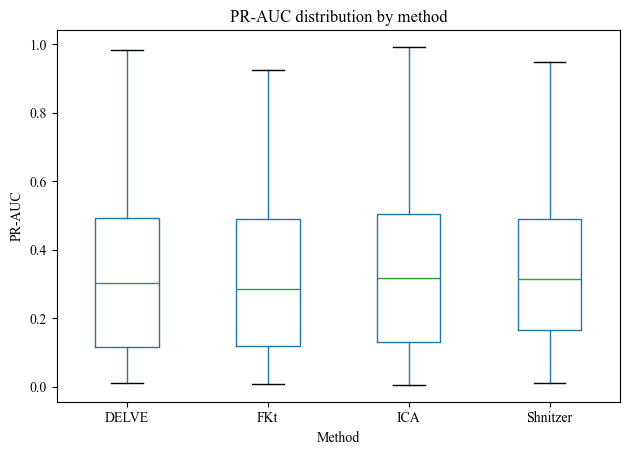

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

df_results.boxplot(
    column="pr_auc",
    by="method",
    grid=False
)

plt.suptitle("")  # remove automatic title
plt.title("PR-AUC distribution by method")
plt.xlabel("Method")
plt.ylabel("PR-AUC")
plt.tight_layout()
plt.show()


<Figure size 1000x400 with 0 Axes>

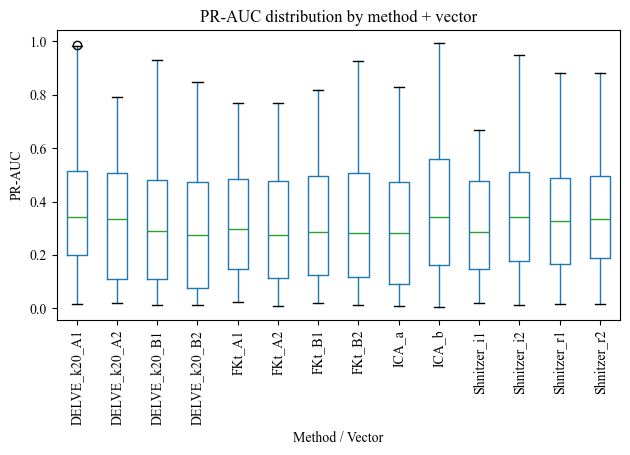

In [124]:
plt.figure(figsize=(10, 4))

df_results.boxplot(
    column="pr_auc",
    by="method_vector",
    grid=False,
    rot=90
)

plt.suptitle("")
plt.title("PR-AUC distribution by method + vector")
plt.xlabel("Method / Vector")
plt.ylabel("PR-AUC")
plt.tight_layout()
plt.show()


In [183]:
# METHODS_plot = {
#     "Shnitzer": ["r1", "r2", "i1", "i2"],
#     "FKt": ["A1", "A2", "B1", "B2"],
#     "DiLVE": [
#         "k10_A1", "k10_A2", "k10_B1", "k10_B2",
#         "k15_A1", "k15_A2", "k15_B1", "k15_B2",
#         "k20_A1", "k20_A2", "k20_B1", "k20_B2",
#         "k25_A1", "k25_A2", "k25_B1", "k25_B2",
#     ],
#     "ICA": ["a","b"]
# }

METHODS_plot = {
    "Shnitzer": ["r1", "i1"],
    "FKt": ["A1", "B1"],
    "DiLVE": ["k20_A1", "k20_B1"],
    "ICA": ["a", "b"],
}

method_order = []
family_of = {}

for family, labels in METHODS_plot.items():
    for lab in labels:
        name = f"{family}_{lab}"
        method_order.append(name)
        family_of[name] = family
df_plot = df_new[df_new["method"].isin(method_order)].copy()



In [184]:
family_cmaps = {
    "Shnitzer": plt.cm.Reds,
    "FKt": plt.cm.Blues,
    "DiLVE": plt.cm.Greens,
    "ICA": plt.cm.Purples,
}

method_colors = {}

for family, labels in METHODS_plot.items():
    cmap = family_cmaps[family]
    n = len(labels)
    shades = np.linspace(0.4, 0.8, n)   # light → dark

    for lab, shade in zip(labels, shades):
        method = f"{family}_{lab}"
        method_colors[method] = cmap(shade)


In [185]:
def colored_boxplot(ax, data, positions, colors):
    bp = ax.boxplot(
        data,
        positions=positions,
        patch_artist=True,
        widths=0.6,
        showfliers=False,
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")

    for element in ["whiskers", "caps", "medians"]:
        for item in bp[element]:
            item.set_color("black")

    return bp


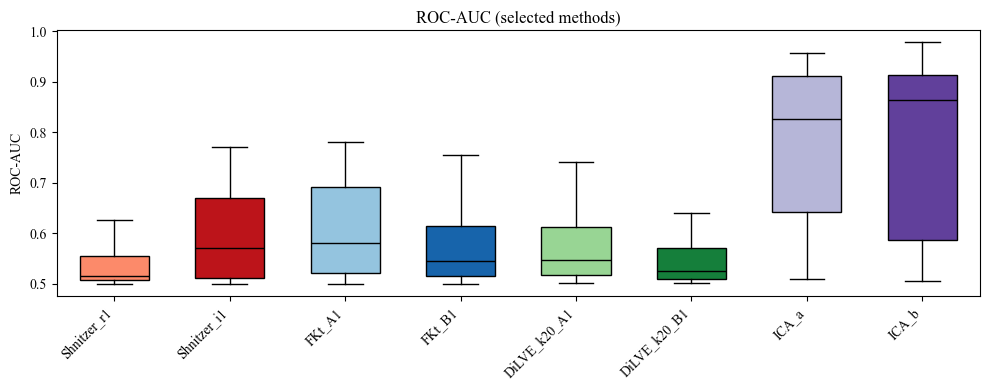

In [186]:
fig, ax = plt.subplots(figsize=(10, 4))

data = [
    df_plot[df_plot["method"] == m]["ROC_AUC"].values
    for m in method_order
]

colors = [method_colors[m] for m in method_order]
positions = np.arange(1, len(method_order) + 1)

colored_boxplot(ax, data, positions, colors)

ax.set_xticks(positions)
ax.set_xticklabels(method_order, rotation=45, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC (selected methods)")

plt.tight_layout()
plt.show()


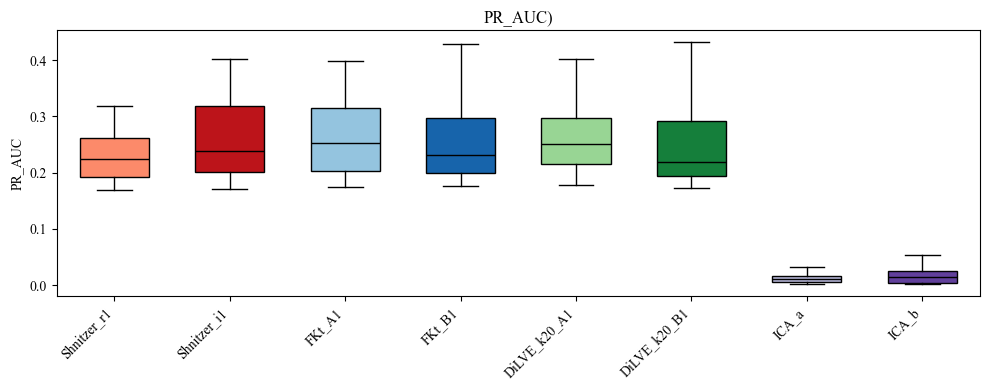

In [187]:
fig, ax = plt.subplots(figsize=(10, 4))

data = [
    df_plot[df_plot["method"] == m]["PR_AUC"].values
    for m in method_order
]

colors = [method_colors[m] for m in method_order]
positions = np.arange(1, len(method_order) + 1)

colored_boxplot(ax, data, positions, colors)

ax.set_xticks(positions)
ax.set_xticklabels(method_order, rotation=45, ha="right")
ax.set_ylabel("PR_AUC")
ax.set_title("PR_AUC)")

plt.tight_layout()
plt.show()

In [211]:
METHODS_plot = {
    "Shnitzer": ["r1", "r2", "i1", "i2"],
    "FKt": ["A1", "A2", "B1", "B2"],
    "DiLVE": [
        "k10_A1", "k10_A2", "k10_B1", "k10_B2",
        "k15_A1", "k15_A2", "k15_B1", "k15_B2",
        "k20_A1", "k20_A2", "k20_B1", "k20_B2",
        "k25_A1", "k25_A2", "k25_B1", "k25_B2",
    ],
    "ICA": ["a","b"]
}

method_order = []
for base, labels in METHODS_plot.items():
    for lab in labels:
        method_order.append(f"{base}_{lab}")
method_order = [m for m in method_order if m in df_new["method"].unique()]




<Figure size 1400x500 with 0 Axes>

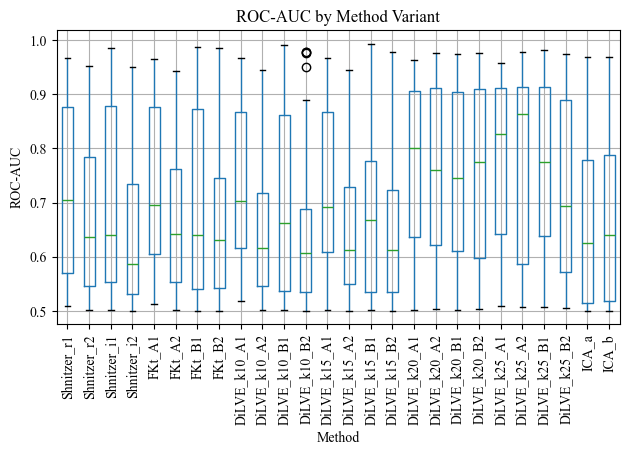

In [212]:
plt.figure(figsize=(14, 5))
df_new.boxplot(
    column="ROC_AUC",
    by="method",
    positions=range(len(method_order)),
)
plt.xticks(range(0, len(method_order) ), method_order, rotation=90)
plt.title("ROC-AUC by Method Variant")
plt.suptitle("")
plt.ylabel("ROC-AUC")
plt.xlabel("Method")
plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

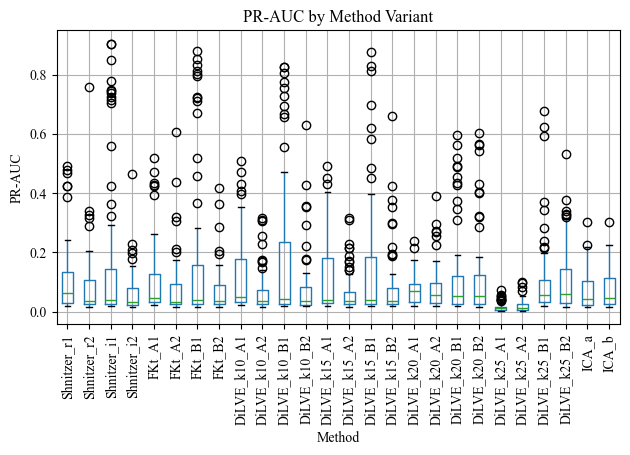

In [213]:
plt.figure(figsize=(14, 5))
df_new.boxplot(
    column="PR_AUC",
    by="method",
    positions=range(len(method_order)),
)
plt.xticks(range(0, len(method_order) ), method_order, rotation=90)
plt.title("PR-AUC by Method Variant")
plt.suptitle("")
plt.ylabel("PR-AUC")
plt.xlabel("Method")
plt.tight_layout()
plt.show()

In [53]:
df = pd.DataFrame(results)
print(df.shape)
print(df["method"].unique())
print(df["tol"].unique())

(8840, 12)
['Shnitzer_r1' 'Shnitzer_r2' 'Shnitzer_i1' 'Shnitzer_i2' 'FKt_A1' 'FKt_A2'
 'FKt_B1' 'FKt_B2' 'DiLVE_k10_A1' 'DiLVE_k10_A2' 'DiLVE_k10_B1'
 'DiLVE_k10_B2' 'DiLVE_k15_A1' 'DiLVE_k15_A2' 'DiLVE_k15_B1'
 'DiLVE_k15_B2' 'DiLVE_k20_A1' 'DiLVE_k20_A2' 'DiLVE_k20_B1'
 'DiLVE_k20_B2' 'DiLVE_k25_A1' 'DiLVE_k25_A2' 'DiLVE_k25_B1'
 'DiLVE_k25_B2' 'ICA_a' 'ICA_b']
[ 10  50  75 100 150]


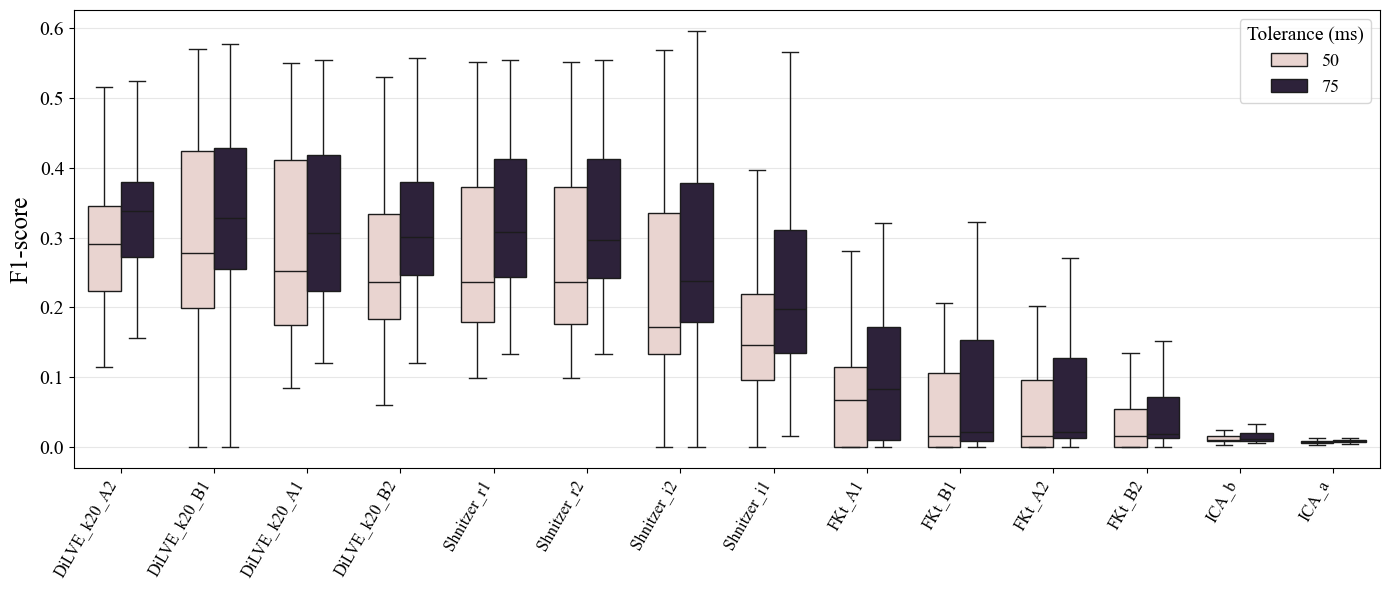

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Filter tolerances
# ----------------------------
df_plot = df[df["tol"].isin([50, 75])].copy()
# For DiLVE, keep only rows with "_25_" in the method name
df_plot = df_plot[
    (~df_plot["method"].str.startswith("DiLVE")) |  # keep Shnitzer/FKt
    (df_plot["method"].str.contains("_k20_"))       # only DiLVE k=25
].copy()

# Optional: sort methods by median F1 (makes plot readable)
method_order = (
    df_plot
    .groupby("method")["f1"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_plot,
    x="method",
    y="f1",
    hue="tol",
    order=method_order,
    showfliers=False,
    width=0.7
)

plt.xticks(rotation=60, ha="right", fontsize=12)
plt.yticks(fontsize=14)

plt.xlabel("")
plt.ylabel("F1-score", fontsize=18)

plt.legend(
    title="Tolerance (ms)",
    fontsize=13,
    title_fontsize=14
)

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("ECG_all_methods_tol_50_75.pdf")
plt.show()


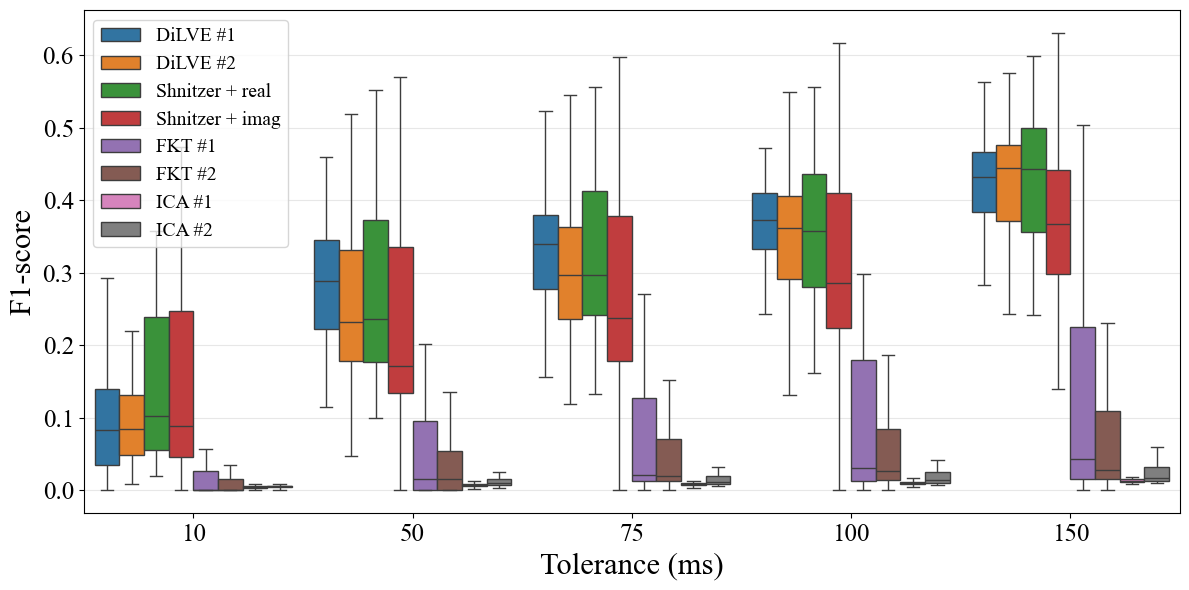

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Map real method names to final legend labels
# ----------------------------
method_map = {
    # DiLVE
    # 'DiLVE_k15_A1': 'DiLVE #1',
    # 'DiLVE_k15_B1': 'DiLVE #2',
        # Second eigenvector (if you want)
    'DiLVE_k15_A2': 'DiLVE #1',
    'DiLVE_k15_B2': 'DiLVE #2',
    # Shnitzer
    # 'Shnitzer_r1': 'Shnitzer + real',
    # 'Shnitzer_i1': 'Shnitzer + imag',
        # Second eigenvector (if you want)
    'Shnitzer_r2': 'Shnitzer + real',
    'Shnitzer_i2': 'Shnitzer + imag',
    # FKt
    # 'FKt_A1': 'FKT #1',
    # 'FKt_B1': 'FKT #2',
        # Second eigenvector (if you want)
    'FKt_A2': 'FKT #1',
    'FKt_B2': 'FKT #2',
    # ICA
    'ICA_a': 'ICA #1',
    'ICA_b': 'ICA #2',
    
   
    
   
}

# Apply the mapping
df_plot = df[df['method'].isin(method_map.keys())].copy()
df_plot['method_label'] = df_plot['method'].map(method_map)

# ----------------------------
# Custom orders
# ----------------------------
tol_order = [10, 50, 75, 100, 150]
method_order = list(dict.fromkeys(method_map.values()))  # preserves order, removes duplicates

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=df_plot,
    x='tol',
    y='f1',
    hue='method_label',
    order=tol_order,
    hue_order=method_order,
    showfliers=False,
    width=0.9
)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("Tolerance (ms)", fontsize=22)
plt.ylabel("F1-score", fontsize=22)
handles, _ = plt.gca().get_legend_handles_labels()

plt.legend(handles, method_map.values(),fontsize=14)

# plt.legend(title="Method", fontsize=16, title_fontsize=13, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ECG_custom_labels.pdf")
plt.show()


In [150]:
import pandas as pd

# Filter for tol = 50
df_summary = df[(df['method'].isin(method_map.keys())) & (df['tol'] == 50)].copy()
df_summary['method_label'] = df_summary['method'].map(method_map)

# List of metrics
metrics = ['f1', 'precision', 'recall']

# Initialize DataFrame
methods = df_summary['method_label'].unique()
summary = pd.DataFrame(index=methods, columns=[f"{m} - Median (SD)" for m in metrics])

# Fill table
for method in methods:
    df_m = df_summary[df_summary['method_label'] == method]
    for m in metrics:
        summary.loc[method, f"{m} - Median (SD)"] = f"{df_m[m].median():.3f} ({df_m[m].std():.3f})"

# Optional: order methods like in plot
method_order = list(dict.fromkeys(method_map.values()))
summary = summary.reindex(method_order)

display(summary)

# Save as LaTeX
latex_table = summary.to_latex(escape=False, caption="ECG Methods Performance at Tolerance = 50 ms", label="tab:ecg_summary", column_format="lccc")
with open("ECG_summary_table.tex", "w") as f:
    f.write(latex_table)


,f1 - Median (SD),precision - Median (SD),recall - Median (SD)
DiLVE #1,0.205 (0.053),0.155 (0.046),0.338 (0.105)
DiLVE #2,0.200 (0.048),0.163 (0.046),0.300 (0.085)
Shnitzer + real,0.193 (0.047),0.151 (0.042),0.281 (0.070)
Shnitzer + imag,0.160 (0.057),0.114 (0.058),0.247 (0.101)
FKT #1,0.012 (0.059),0.135 (0.238),0.006 (0.080)
FKT #2,0.012 (0.054),0.172 (0.280),0.006 (0.065)
ICA #1,0.009 (0.002),0.005 (0.001),0.062 (0.023)
ICA #2,0.011 (0.006),0.006 (0.004),0.081 (0.034)
